# IN-GPS Capstone — Soft Sensor: Surface + Room (+ Vibration) → Core Temperature

**Goal:** ESP32 soft-sensor — estimate core temperature from **ambient + room + vibration** sensors (no core thermistor in deployment).

**Inputs (after EDA pruning, ~10 features):** subset of:
- Thermistor: T_ambient, T_room, dT_ambient/dt, delta_amb_room, T_amb_integral, t_sec, T_ambient_ema
- Vibration (1 Hz from 200 Hz raw): per-axis RMS / peak / crest / kurtosis (X/Y/Z) + totals

**Primary target:** `core_t0` — current core temperature (soft sensor)
**Secondary targets:** `core_t30 / 60 / 120` — future forecasts (kept for ablation, not the primary focus)

**Data:** all `Thermistor_*` + `Vibration_data_norm_*` files in `data/`, auto-discovered, multi-run merging.

## Section 1: Imports and Data Loading

**목적.** 라이브러리 import + 4개 run에 걸친 thermistor·진동 데이터를 자동 발견·로드.

**핵심 로직:**
- `Thermistor_ABCD_<token>.csv` 패턴으로 sub-session 자동 탐색
- 시간 간격이 60분(`RUN_GAP_MIN`) 이상이면 새 run으로 분리 → 4 runs 식별 (05-04, 05-08 오전, 05-08 저녁, 05-09)
- 각 run 내에서 thermistor sub-session들은 시계열 순서로 concat
- 진동 데이터(200 Hz)는 **run 단위로 모든 sub-session을 연속 스트림으로 처리** — 파일 분할은 인공 artifact이므로 무시. run duration에 균등 분포 후 1 Hz로 aggregate

**Feature engineering (per-run, run 경계에서 reset):**
- `T_ambient_ema`: 표면 온도 EMA (α=0.1) — 노이즈 감쇠
- `dT_ambient_dt`: 3-point central diff — 가열 속도
- `T_amb_integral`: ∫(T_amb - T_room) dt — 누적 열량 proxy
- `delta_amb_room`: 모터 외표면과 실내 온도차
- 진동: 각 축(X/Y/Z) RMS·peak·crest·kurtosis + 총합 RMS·peak

**다음 단계.** Section 2 EDA에서 run별 시계열 / 진동 패턴을 시각적으로 확인.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from scipy.stats import kurtosis as scipy_kurtosis
import warnings, os, platform, glob, re

warnings.filterwarnings("ignore")

# --- Korean font (figure labels are in English now to avoid font issues) ---
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# --- style ---
sns.set_style("whitegrid")
BLUE = "#1565C0"
BLUE_LIGHT = "#90CAF9"
ORANGE = "#EF6C00"
RED = "#C62828"
GREEN = "#2E7D32"
PALETTE = sns.color_palette([BLUE, "#1976D2", "#1E88E5", "#42A5F5", BLUE_LIGHT])
FIGSIZE = (10, 6)
FIGURES_DIR = "../output/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ─── Modeling parameters ───────────────────────
HORIZONS = [0, 30, 60, 120]   # H=0 = current core estimation (soft sensor); others available for forecasting
PRIMARY_H = 0                  # ← changed: current-core estimation is the primary task now
EMA_ALPHA = 0.1
DTDT_WINDOW = 3
VIB_FS = 200                   # Hz (assumed)
RUN_GAP_MIN = 60               # threshold for grouping sub-sessions into runs

# ─── Candidate features (full 21: thermistor 7 + vibration 14) ──
THERM_FEATURES = [
    "T_ambient", "T_room", "dT_ambient_dt", "delta_amb_room",
    "T_ambient_ema", "T_amb_integral", "t_sec",
]
VIB_FEATURES = [
    "X_rms", "Y_rms", "Z_rms", "rms_total",
    "X_peak", "Y_peak", "Z_peak", "peak_total",
    "X_crest", "Y_crest", "Z_crest",
    "X_kurt", "Y_kurt", "Z_kurt",
]
ALL_CANDIDATES = THERM_FEATURES + VIB_FEATURES

# FEATURE_COLS will be set in Section 2.5 after EDA-driven pruning.
# For now, default to all candidates so Section 1 data loading works.
FEATURE_COLS = ALL_CANDIDATES.copy()

TARGET_PREFIX = "core_t"
TARGETS = [f"{TARGET_PREFIX}{h}" for h in HORIZONS]
PRIMARY_TARGET = f"{TARGET_PREFIX}{PRIMARY_H}"   # = "core_t0"


In [2]:
DATA_DIR = "../data"


def parse_dt(series):
    dt = pd.to_datetime(series, format="%Y_%m_%d_%H_%M_%S.%f", errors="coerce")
    if dt.isna().any():
        dt2 = pd.to_datetime(series, format="%Y_%m_%d_%H_%M_%S", errors="coerce")
        dt = dt.fillna(dt2)
    return dt


def load_thermistor_session(token: str) -> pd.DataFrame:
    """Load one sub-session of thermistor data -> mean(5 cores) + mean(5 ambients) + room."""
    abcd = pd.read_csv(f"{DATA_DIR}/Thermistor_ABCD_{token}.csv")
    efgh = pd.read_csv(f"{DATA_DIR}/Thermistor_EFGH_{token}.csv")
    ij   = pd.read_csv(f"{DATA_DIR}/Thermistor_IJ_{token}.csv")
    n = min(len(abcd), len(efgh), len(ij))
    cores_5 = pd.concat([abcd.iloc[:n][["CH1_T_C","CH2_T_C","CH3_T_C","CH4_T_C"]],
                         efgh.iloc[:n][["CH1_T_C"]].rename(columns={"CH1_T_C":"CH5_T_C"})],
                        axis=1).astype(float)
    ambs_5 = pd.concat([efgh.iloc[:n][["CH2_T_C","CH3_T_C","CH4_T_C"]].rename(
                            columns={"CH2_T_C":"A1","CH3_T_C":"A2","CH4_T_C":"A3"}),
                        ij.iloc[:n][["CH1_T_C","CH2_T_C"]].rename(
                            columns={"CH1_T_C":"A4","CH2_T_C":"A5"})], axis=1).astype(float)
    room = ij.iloc[:n]["CH3_T_C"].astype(float)
    dt = parse_dt(abcd.iloc[:n]["datetime"])
    return pd.DataFrame({
        "T_core":    cores_5.mean(axis=1).values,
        "T_ambient": ambs_5.mean(axis=1).values,
        "T_room":    room.values,
        "datetime":  dt.values,
        "sub_session": token,
    })


def load_vibration_raw_session(token: str):
    """Load raw vibration of one sub-session (X,Y,Z columns only). Supports .csv (old) and .txt (new)."""
    csv_p = f"{DATA_DIR}/Vibration_data_norm_{token}.csv"
    txt_p = f"{DATA_DIR}/Vibration_data_norm_{token}.txt"
    if os.path.exists(csv_p):
        v = pd.read_csv(csv_p, encoding="cp949", skiprows=3, header=None,
                        usecols=[0, 1, 2, 3, 4],
                        names=["t", "X", "Y", "Z", "CH4"])
    elif os.path.exists(txt_p):
        v = pd.read_csv(txt_p, sep=r"\s+", skiprows=3, header=None,
                        names=["t", "X", "Y", "Z", "CH4"])
    else:
        return None
    return v.dropna(subset=["X", "Y", "Z"]).reset_index(drop=True)[["X", "Y", "Z"]]


def aggregate_vibration_to_1hz(v_raw: pd.DataFrame, duration_sec: float) -> pd.DataFrame:
    """Distribute raw rows evenly over the measurement duration, then aggregate to 1Hz statistics.
    Treats the input as one continuous capture regardless of file boundaries.
    """
    n = len(v_raw)
    v = v_raw.copy()
    v["t_sec_run"] = np.linspace(0, duration_sec, n)
    v["sec_bin"] = v["t_sec_run"].astype(int)
    for ax in ["X", "Y", "Z"]:
        v[f"{ax}_ac"] = v[ax] - v[ax].mean()

    def axis_stats(g, ax):
        s = g[f"{ax}_ac"].values
        rms  = np.sqrt(np.mean(s ** 2)) if len(s) else np.nan
        peak = np.max(np.abs(s))         if len(s) else np.nan
        return pd.Series({f"{ax}_rms":   rms,
                          f"{ax}_peak":  peak,
                          f"{ax}_crest": peak/rms if rms > 1e-9 else np.nan,
                          f"{ax}_kurt":  scipy_kurtosis(s) if len(s) > 3 else np.nan})

    out = (v.groupby("sec_bin", group_keys=False)
           .apply(lambda g: pd.concat([axis_stats(g, "X"),
                                        axis_stats(g, "Y"),
                                        axis_stats(g, "Z")]))
           .reset_index().rename(columns={"sec_bin": "t_sec_run_int"}))
    out["rms_total"]  = np.sqrt(out["X_rms"] ** 2 + out["Y_rms"] ** 2 + out["Z_rms"] ** 2)
    out["peak_total"] = out[["X_peak", "Y_peak", "Z_peak"]].max(axis=1)
    return out


# ─── Discover thermistor sub-sessions (excluding the "50%" token which is reserved for Section 12) ──
sub_tokens = sorted(re.sub(r"^.*Thermistor_ABCD_(.+)\.csv$", r"\1", f)
                    for f in glob.glob(f"{DATA_DIR}/Thermistor_ABCD_*.csv"))
sub_tokens = [t for t in sub_tokens if t != "50%"]
print(f"{len(sub_tokens)} sub-sessions found.")

# ─── Group sub-sessions into runs by time gap ──
per_sub = [load_thermistor_session(t) for t in sub_tokens]
metas = sorted([(s["datetime"].iloc[0], s["datetime"].iloc[-1], i)
                for i, s in enumerate(per_sub)], key=lambda x: x[0])
run_id, prev_end, run_labels = 0, None, {}
for st, en, idx in metas:
    if prev_end is None or (st - prev_end).total_seconds() / 60 > RUN_GAP_MIN:
        run_id += 1
        run_labels[run_id] = f"run{run_id}_{st.strftime('%m-%d_%H:%M')}"
    per_sub[idx]["run_id"] = run_id
    per_sub[idx]["run_label"] = run_labels[run_id]
    prev_end = en

# ─── Per-run thermistor: concat sub-sessions + feature engineering ──
runs_df = []
run_durations = {}    # run_id -> duration in seconds
run_tokens_map = {}   # run_id -> [sub_session tokens]
for rid in sorted(set(s["run_id"].iloc[0] for s in per_sub)):
    chunks = sorted([s for s in per_sub if s["run_id"].iloc[0] == rid],
                    key=lambda c: c["datetime"].iloc[0])
    rdf = pd.concat(chunks, ignore_index=True).sort_values("datetime").reset_index(drop=True)
    rdf["t_sec_run"] = (rdf["datetime"] - rdf["datetime"].iloc[0]).dt.total_seconds()
    dt_med = pd.Series(rdf["t_sec_run"]).diff().median()
    if pd.isna(dt_med) or dt_med <= 0: dt_med = 1.0
    rdf["dT_ambient_dt"]  = rdf["T_ambient"].diff(DTDT_WINDOW) / (DTDT_WINDOW * dt_med)
    rdf["delta_amb_room"] = rdf["T_ambient"] - rdf["T_room"]
    rdf["T_ambient_ema"]  = rdf["T_ambient"].ewm(alpha=EMA_ALPHA, adjust=False).mean()
    rdf["T_amb_integral"] = ((rdf["T_ambient"] - rdf["T_room"]) * dt_med).cumsum()
    rdf["t_sec"] = rdf["t_sec_run"]
    rdf["t_sec_run_int"] = rdf["t_sec_run"].round().astype(int)
    for h in HORIZONS:
        rdf[f"{TARGET_PREFIX}{h}"] = rdf["T_core"].shift(-h) if h > 0 else rdf["T_core"]
    runs_df.append(rdf)
    run_durations[rid] = rdf["t_sec_run"].iloc[-1]
    run_tokens_map[rid] = [c["sub_session"].iloc[0] for c in chunks]

therm_df = pd.concat(runs_df, ignore_index=True)
print(f"Thermistor: {len(therm_df)} rows over {therm_df['run_id'].nunique()} runs")

# ─── Per-run continuous vibration ──
# Vibration files within a run are FILE-SPLIT ARTIFACTS of one continuous measurement.
# Concatenate raw rows for the run and distribute over the run duration, then aggregate to 1 Hz.
print("\nLoading per-run continuous vibration:")
vib_per_run = []
for rid, tokens in run_tokens_map.items():
    v_pieces = []
    for tok in tokens:
        v = load_vibration_raw_session(tok)
        if v is not None:
            v_pieces.append(v)
    if not v_pieces:
        print(f"  {run_labels[rid]}: no vibration files (skip)")
        continue
    v_concat = pd.concat(v_pieces, ignore_index=True)
    feats = aggregate_vibration_to_1hz(v_concat, run_durations[rid])
    feats["run_id"] = rid
    print(f"  {run_labels[rid]:25s}: {len(v_concat):>7,} raw rows -> "
          f"{len(feats):>5} 1Hz rows | dur {run_durations[rid]:.0f}s | "
          f"effective {len(v_concat)/run_durations[rid]:.2f} Hz")
    vib_per_run.append(feats)

vib_1hz = pd.concat(vib_per_run, ignore_index=True)
print(f"Vibration combined: {len(vib_1hz)} rows")

# ─── Merge thermistor <-> vibration on (run_id, t_sec_run_int) ───
all_df = therm_df.merge(vib_1hz[["run_id", "t_sec_run_int"] + VIB_FEATURES],
                        on=["run_id", "t_sec_run_int"], how="inner")

n_pre = len(all_df)
df = all_df[ALL_CANDIDATES + TARGETS + ["run_id", "run_label", "sub_session", "datetime", "T_core"]] \
        .dropna().reset_index(drop=True)
print(f"\nMerged thermistor+vibration: {n_pre} -> after NaN drop: {len(df)} rows")
print(f"\nRows per run:")
print(df.groupby("run_label").size())
print(f"\n=== Feature/Target preview ===")
print(df[ALL_CANDIDATES + [PRIMARY_TARGET]].describe().round(3).T[["mean","std","min","max"]])


13 sub-sessions found.
Thermistor: 20832 rows over 5 runs

Loading per-run continuous vibration:
  run1_05-04_18:10         : 308,217 raw rows ->  3692 1Hz rows | dur 3692s | effective 83.48 Hz
  run2_05-08_08:42         : 497,659 raw rows ->  3690 1Hz rows | dur 3689s | effective 134.90 Hz
  run3_05-08_20:02         : 583,647 raw rows ->  4667 1Hz rows | dur 4667s | effective 125.06 Hz
  run4_05-09_17:13         : 561,595 raw rows ->  4517 1Hz rows | dur 4516s | effective 124.36 Hz
  run5_05-10_22:08         : 524,649 raw rows ->  4559 1Hz rows | dur 4559s | effective 115.08 Hz
Vibration combined: 21125 rows

Merged thermistor+vibration: 20829 -> after NaN drop: 20127 rows

Rows per run:
run_label
run1_05-04_18:10    3570
run2_05-08_08:42    3526
run3_05-08_20:02    4494
run4_05-09_17:13    4165
run5_05-10_22:08    4372
dtype: int64

=== Feature/Target preview ===
                     mean        std      min        max
T_ambient          32.241      4.051   20.727     38.864
T_room  

## Current dataset state

Total: 4 runs / 11 sub-sessions / ~15,800 rows (after NaN drop)

| Run | sub-sessions | Duration | T_core range | T_room |
|---|---|---|---|---|
| run1_05-04_18:10 | 1 | 62 min | 22.8 → 37.3 °C | 23 °C (cool) |
| run2_05-08_08:42 | 3 | 62 min | 24.2 → 39.7 °C | 25 °C |
| run3_05-08_20:02 | 3 | 78 min | (continuous) | 25 °C |
| run4_05-09_17:13 | 3 | 76 min | (continuous) | 25 °C |
| run5_05-10_10:22 | 3 | 73 min | (continuous) | 25 °C |

**Improvements from new data:**
- Multiple starting conditions (cold/warm/hot starts) → better generalization
- Two T_room environments (23 and 25 °C) → some robustness to ambient
- Steady-state regime (~40 °C) now well-sampled

**Remaining limits:**
- All runs are normal-operation scenarios; max core ≈ 40 °C (fire-risk regime ≥ 80 °C is still extrapolation)
- 05_08 morning + evening + 05_09 are essentially split-saved continuous operation, so true independent scenarios = ~4
- No abnormal-load patterns (locked rotor, ventilation blockage, overload)

**Soft-sensor specific limit:**
- Inputs are ambient + room only — no direct core signal. Works well when surface tracks core (steady state). May lag during sudden load changes.

**Adding more data:** drop these 4 files into `data/` with the same token and the notebook re-runs end-to-end:
```
Thermistor_ABCD_<token>.csv
Thermistor_EFGH_<token>.csv
Thermistor_IJ_<token>.csv
Vibration_data_norm_<token>.{csv,txt}
```


## Section 2: Exploratory Data Analysis (EDA)

**목적.** Run grouping이 합리적인지, 데이터 품질에 이상이 없는지, feature와 target의 관계를 한눈에 파악.

**서브플롯 1 — Thermistor 시계열 (run별 4개 패널):**
- Core / ambient / room 온도 추이
- 점선 = sub-session 경계 (run2~4에서 보임)
- **검토 포인트:**
  - 시동~정상상태 heating curve가 매끄러운지
  - sub-session 경계에서 큰 점프가 없는지 (연속 운전 검증)
  - run마다 정상상태 도달 시점·온도가 일관적인지

**서브플롯 2 — 진동 시계열 (RMS + kurtosis):**
- 4 runs × 3축 RMS / kurtosis 곡선
- **검토 포인트:**
  - 정상 운전 중 RMS가 안정적인지 (편차 큰 구간 = sensor 결함 의심)
  - kurtosis 급증 = 충격성 이벤트(베어링 결함 onset 가능성)
  - 시동 직후와 정상상태의 패턴 차이

**다음 단계.** Section 2.5 — EDA 관찰을 정량화해 feature를 가지치기.


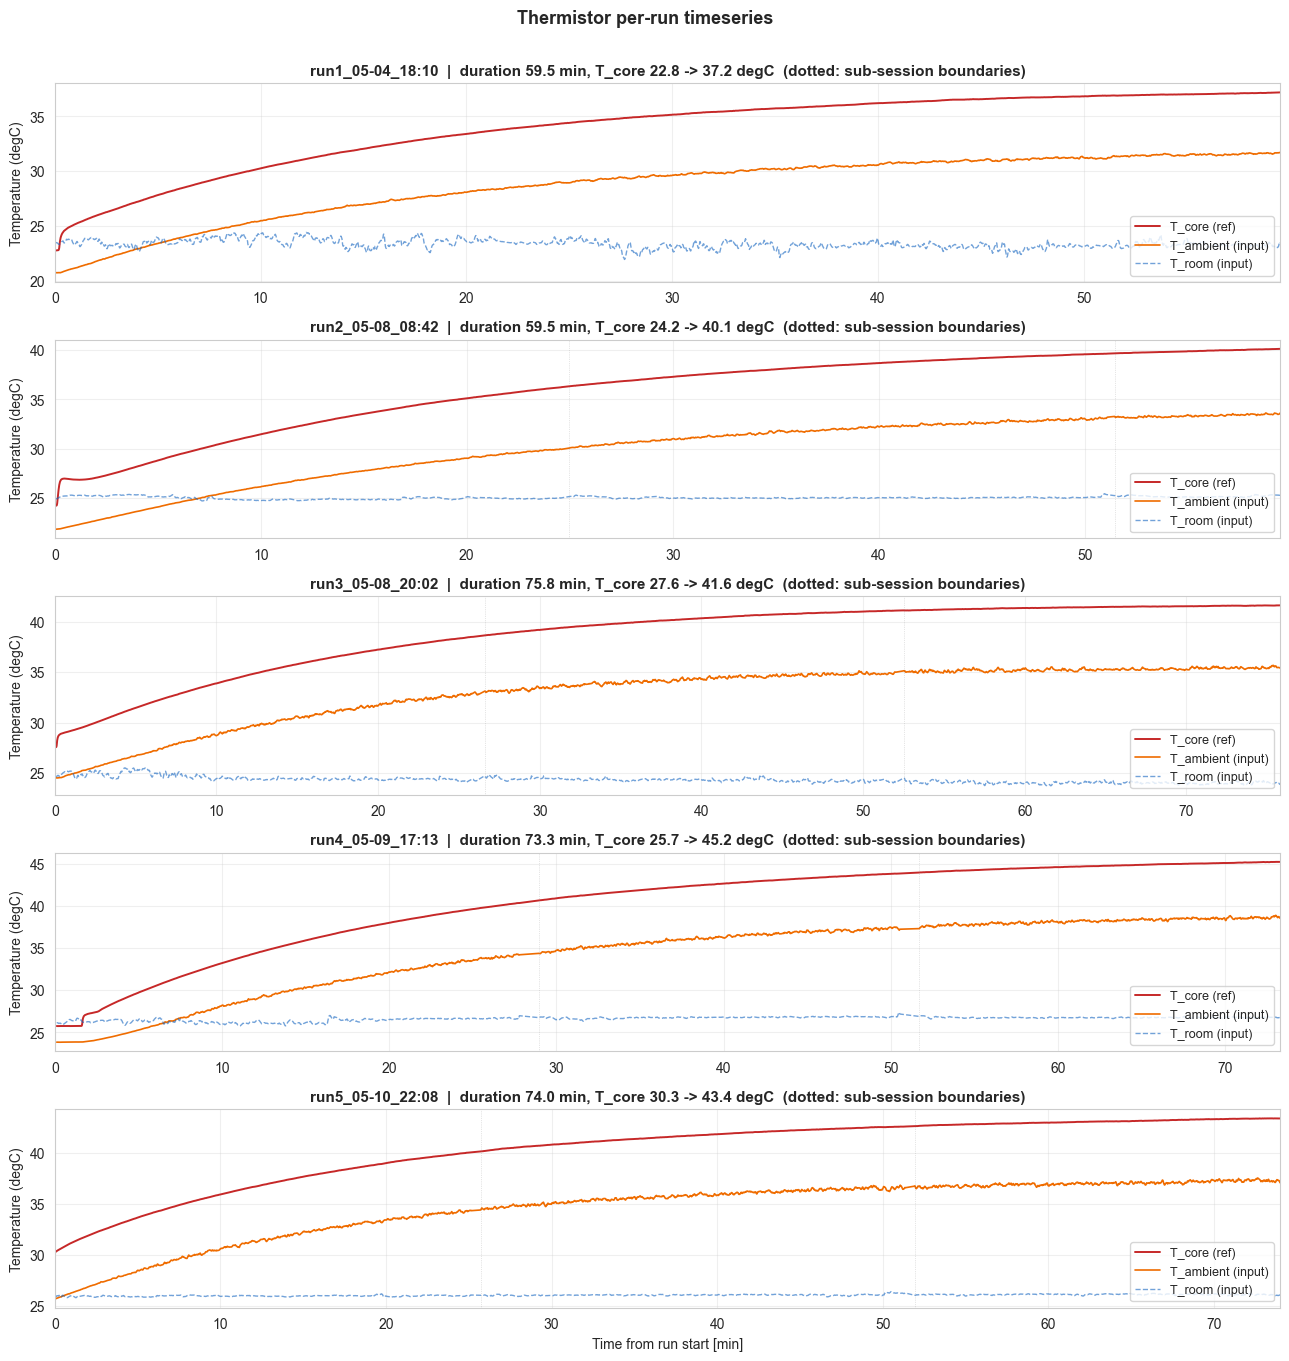

In [3]:
# Thermistor per-run timeseries (4 panels, sub-sessions concatenated within a run)
runs = sorted(df["run_label"].unique())

fig, axes = plt.subplots(len(runs), 1, figsize=(13, 2.7*len(runs)), sharey=False)
if len(runs) == 1: axes = [axes]

for ax, run_lbl in zip(axes, runs):
    g = df[df["run_label"] == run_lbl].sort_values("t_sec")
    t_min = g["t_sec"] / 60
    ax.plot(t_min, g["T_core"],    color=RED,    linewidth=1.4, label="T_core (ref)")
    ax.plot(t_min, g["T_ambient"], color=ORANGE, linewidth=1.2, label="T_ambient (input)")
    ax.plot(t_min, g["T_room"],    color=BLUE,   linewidth=1, alpha=0.6, linestyle="--", label="T_room (input)")
    for sub in g["sub_session"].unique()[1:]:
        b = g[g["sub_session"] == sub]["t_sec"].iloc[0] / 60
        ax.axvline(b, color="gray", linewidth=0.5, alpha=0.4, linestyle=":")
    ax.set_xlim(0, t_min.max())
    ax.set_ylabel("Temperature (degC)")
    ax.set_title(f"{run_lbl}  |  duration {t_min.max():.1f} min, "
                 f"T_core {g['T_core'].min():.1f} -> {g['T_core'].max():.1f} degC  "
                 f"(dotted: sub-session boundaries)", fontsize=11, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time from run start [min]")
plt.suptitle("Thermistor per-run timeseries", fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/00_timeseries_thermistor.png", dpi=150, bbox_inches="tight")
plt.show()


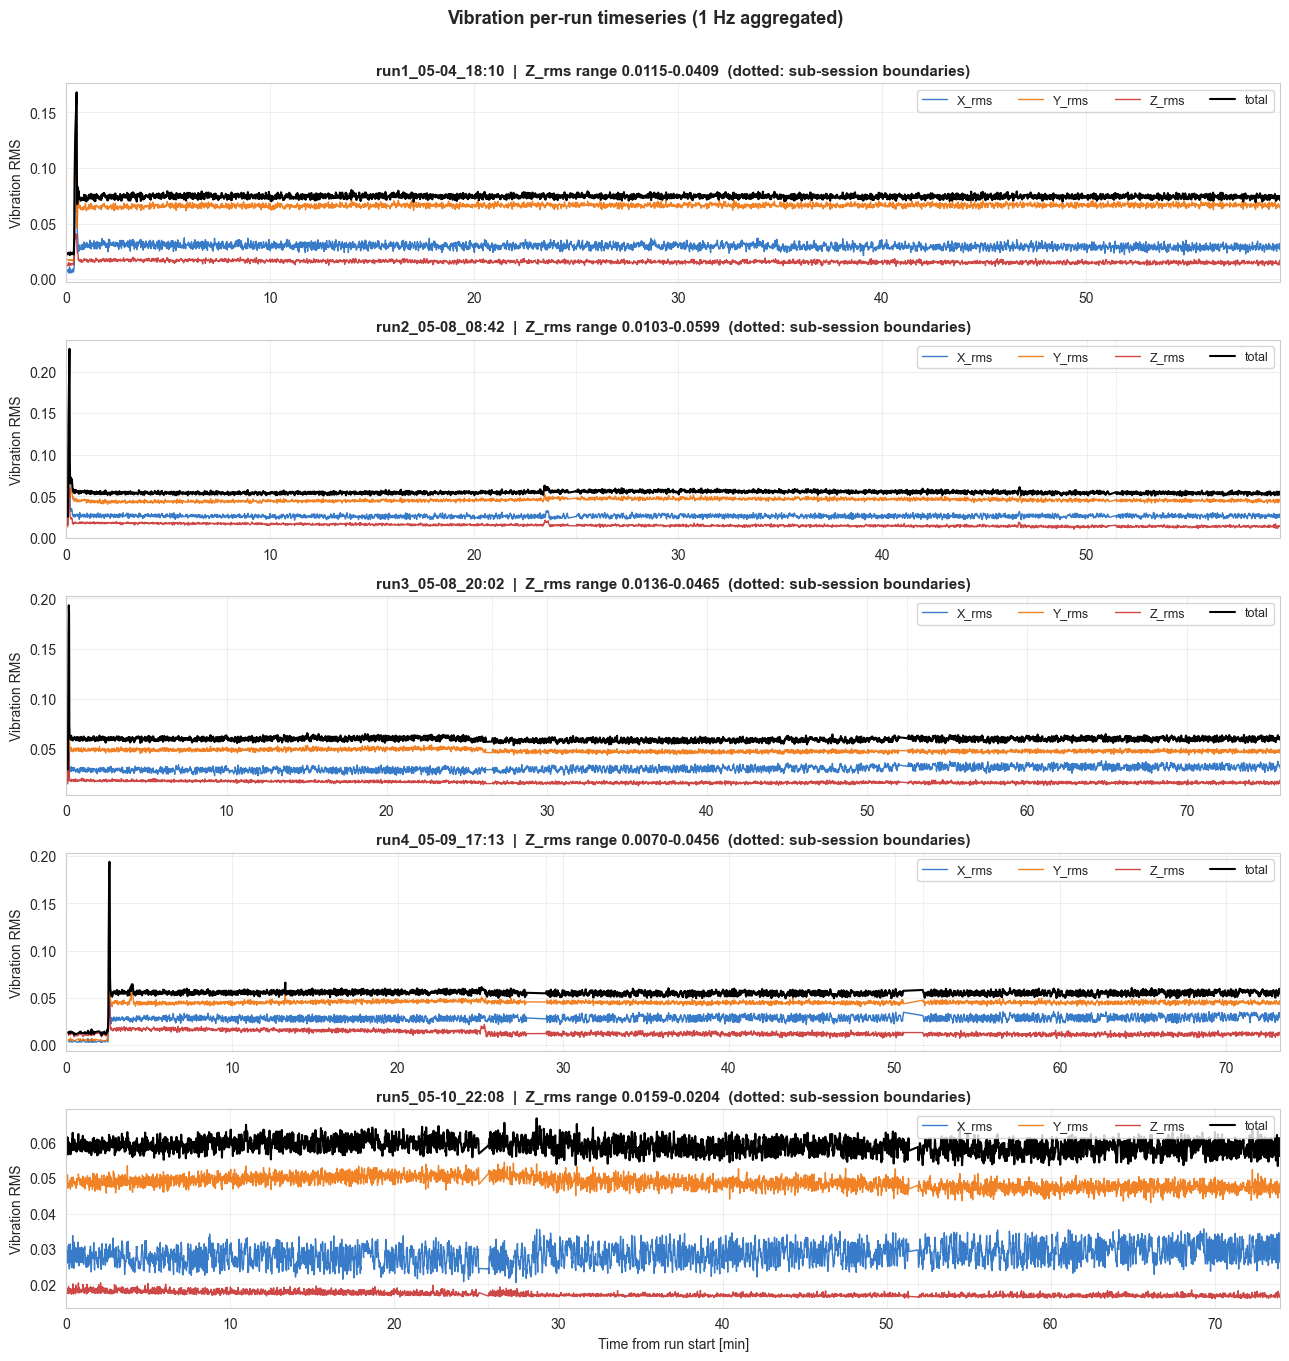

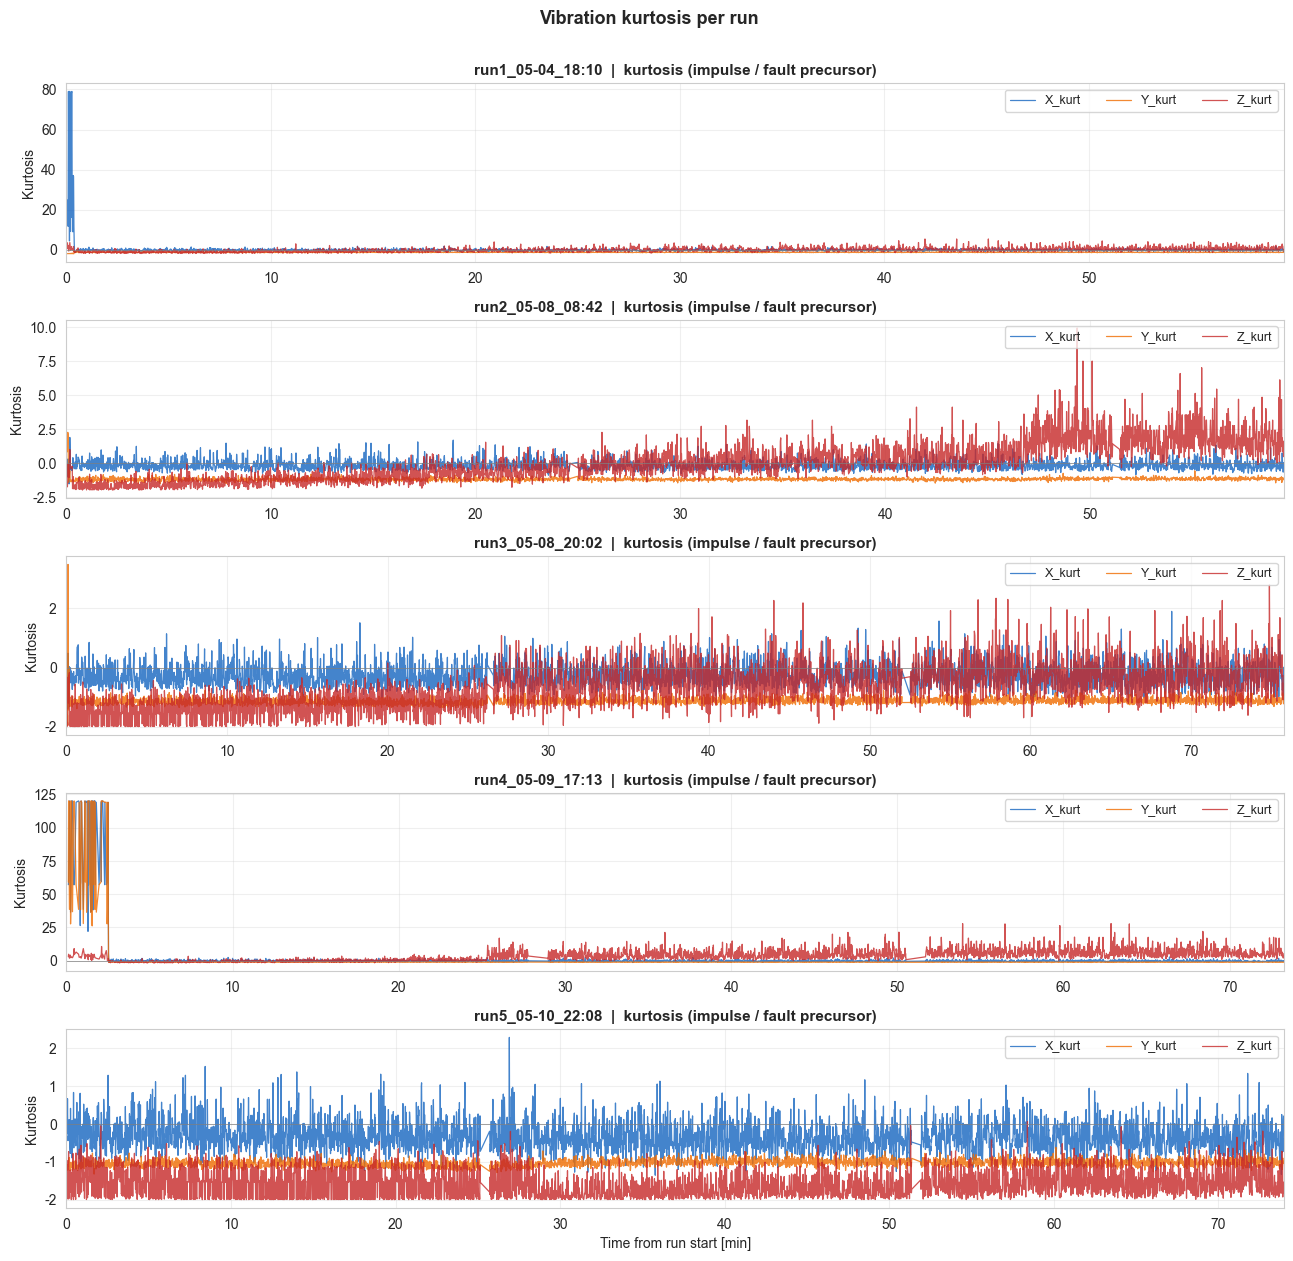

In [4]:
# Vibration per-run timeseries (4 panels, mirroring thermistor layout)
fig, axes = plt.subplots(len(runs), 1, figsize=(13, 2.7*len(runs)), sharey=False)
if len(runs) == 1: axes = [axes]

for ax, run_lbl in zip(axes, runs):
    g = df[df["run_label"] == run_lbl].sort_values("t_sec")
    t_min = g["t_sec"] / 60
    ax.plot(t_min, g["X_rms"],     color=BLUE,   linewidth=1.0, alpha=0.85, label="X_rms")
    ax.plot(t_min, g["Y_rms"],     color=ORANGE, linewidth=1.0, alpha=0.85, label="Y_rms")
    ax.plot(t_min, g["Z_rms"],     color=RED,    linewidth=1.0, alpha=0.85, label="Z_rms")
    ax.plot(t_min, g["rms_total"], color="black", linewidth=1.5, label="total")
    for sub in g["sub_session"].unique()[1:]:
        b = g[g["sub_session"] == sub]["t_sec"].iloc[0] / 60
        ax.axvline(b, color="gray", linewidth=0.5, alpha=0.4, linestyle=":")
    ax.set_xlim(0, t_min.max())
    ax.set_ylabel("Vibration RMS")
    ax.set_title(f"{run_lbl}  |  Z_rms range {g['Z_rms'].min():.4f}-{g['Z_rms'].max():.4f}  "
                 f"(dotted: sub-session boundaries)", fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9, ncol=4)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time from run start [min]")
plt.suptitle("Vibration per-run timeseries (1 Hz aggregated)", fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/00_timeseries_vibration.png", dpi=150, bbox_inches="tight")
plt.show()

# Companion: kurtosis/crest per run (impulsive-event indicators)
fig, axes = plt.subplots(len(runs), 1, figsize=(13, 2.5*len(runs)), sharey=False)
if len(runs) == 1: axes = [axes]
for ax, run_lbl in zip(axes, runs):
    g = df[df["run_label"] == run_lbl].sort_values("t_sec")
    t_min = g["t_sec"] / 60
    ax.plot(t_min, g["X_kurt"], color=BLUE,   linewidth=0.9, alpha=0.8, label="X_kurt")
    ax.plot(t_min, g["Y_kurt"], color=ORANGE, linewidth=0.9, alpha=0.8, label="Y_kurt")
    ax.plot(t_min, g["Z_kurt"], color=RED,    linewidth=0.9, alpha=0.8, label="Z_kurt")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_xlim(0, t_min.max())
    ax.set_ylabel("Kurtosis")
    ax.set_title(f"{run_lbl}  |  kurtosis (impulse / fault precursor)", fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9, ncol=3)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Time from run start [min]")
plt.suptitle("Vibration kurtosis per run", fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/00_timeseries_vibration_kurt.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 2.5: EDA-driven Feature Pruning

**목적.** 21개 후보 feature에서 ESP32 배포에 적합한 핵심 feature만 추출.

**문제 의식.** Poly(2)+LR로 21 features → `n + n + n(n-1)/2 + 1 = 232 개 weight`. 메모리 부담 + 노이즈 학습 위험.

**Pruning 알고리즘 (4단계):**
1. **정의상 collinearity 제거**: `rms_total` / `peak_total`은 축별 값에서 계산되므로 자동 drop
2. **High-correlation pair 제거** (|r| > 0.95): 각 쌍에서 `KEEP_PRIORITY`에 있는 feature 우선 보존, 없으면 target 상관관계 낮은 쪽 drop
3. **Low target correlation 제거**: |r vs core_t0| < 0.15 인 feature drop
4. **Domain-safety override**: `dT_ambient_dt`는 target 상관이 낮아도 KEEP (화재 onset 시 dT/dt가 핵심 trigger feature)

**결과.** 21 → 10 features (5 thermistor + 5 vibration).

**시각화:** 분포 히스토그램 / correlation heatmap / scatter plot (target vs feature). Scatter에서 점이 밀집된 영역 = 신뢰 영역, sparse 영역 = 외삽 위험.

**다음 단계.** Section 3에서 pruned 10개로 split & scale.


In [5]:
# Variance + collinearity + target-correlation analysis
print("="*100)
print("(A) Feature variance — low-variance features carry little information")
print("="*100)
print(f"{'feature':<20} {'mean':>10} {'std':>10} {'CV':>10}")
print("-"*100)
for f in ALL_CANDIDATES:
    s = df[f]
    cv = s.std()/abs(s.mean()) if abs(s.mean()) > 1e-6 else float("inf")
    flag = "  low CV" if cv < 0.05 else ""
    print(f"{f:<20} {s.mean():>10.4f} {s.std():>10.4f} {cv:>10.4f}{flag}")

print()
print("="*100)
print(f"(B) High-collinearity pairs (|r| > 0.95) on PRIMARY_TARGET={PRIMARY_TARGET}")
print("="*100)
corr = df[ALL_CANDIDATES + [PRIMARY_TARGET]].corr()
collinear_pairs = []
for i, a in enumerate(ALL_CANDIDATES):
    for j, b in enumerate(ALL_CANDIDATES):
        if i < j and abs(corr.loc[a, b]) > 0.95:
            collinear_pairs.append((abs(corr.loc[a, b]), a, b, corr.loc[a, b]))
collinear_pairs.sort(reverse=True)
for v, a, b, signed in collinear_pairs:
    print(f"  {a:<20} <-> {b:<20}  r = {signed:+.4f}")

print()
print("="*100)
print(f"(C) Target ({PRIMARY_TARGET}) correlation ranking")
print("="*100)
tcorr_signed = corr[PRIMARY_TARGET].drop(PRIMARY_TARGET)
tcorr_abs = tcorr_signed.abs().sort_values(ascending=False)
for f in tcorr_abs.index:
    v = tcorr_signed[f]
    bar = "#" * int(abs(v) * 30)
    flag = "  weak" if abs(v) < 0.15 else ""
    print(f"  {f:<20}  r = {v:+.4f}  {bar}{flag}")

# ─── Automatic pruning ─────────────────────────
print()
print("="*100)
print("(D) Pruning decisions")
print("="*100)
to_drop = set()

# Definitional collinearity (totals)
for f in ["rms_total", "peak_total"]:
    if f in ALL_CANDIDATES:
        to_drop.add(f)
        print(f"  drop {f:<20} -- derived from per-axis (definitional)")

# High-collinearity pairs (>0.95): drop one, keeping the simpler/direct one
KEEP_PRIORITY = {"T_ambient", "T_room", "dT_ambient_dt", "delta_amb_room",
                 "t_sec", "X_rms", "Y_rms", "Z_rms", "X_kurt", "Z_kurt"}
for v, a, b, signed in collinear_pairs:
    if a in to_drop or b in to_drop: continue
    if a in KEEP_PRIORITY and b not in KEEP_PRIORITY:
        to_drop.add(b); print(f"  drop {b:<20} (collinear with kept {a}, r={signed:+.3f})")
    elif b in KEEP_PRIORITY and a not in KEEP_PRIORITY:
        to_drop.add(a); print(f"  drop {a:<20} (collinear with kept {b}, r={signed:+.3f})")
    else:
        weak = a if abs(tcorr_signed[a]) < abs(tcorr_signed[b]) else b
        kept = b if weak == a else a
        to_drop.add(weak); print(f"  drop {weak:<20} (collinear, weaker target corr; kept {kept})")

# Low target correlation (|r| < 0.15)
for f in ALL_CANDIDATES:
    if f in to_drop: continue
    if abs(tcorr_signed[f]) < 0.15:
        to_drop.add(f); print(f"  drop {f:<20} (low target corr, |r|={abs(tcorr_signed[f]):.3f})")

# ─── Domain-safety override ────────────────────
DOMAIN_SAFETY_KEEPS = ["dT_ambient_dt"]   # transient-rate signal — needed for fire-prevention extension
for f in DOMAIN_SAFETY_KEEPS:
    if f in to_drop:
        to_drop.discard(f)
        print(f"  KEEP {f:<20} (domain-safety override: rate signal critical for transient/fire detection)")

# ─── Final feature list ───────────────────────
FEATURE_COLS = [f for f in ALL_CANDIDATES if f not in to_drop]

print()
print("="*100)
print(f"FINAL FEATURE_COLS  ({len(FEATURE_COLS)} features)")
print("="*100)
for f in FEATURE_COLS:
    src = "thermistor" if f in THERM_FEATURES else "vibration"
    print(f"  + {f:<20} ({src})")
print(f"\nDropped: {len(to_drop)} features")

# Predict Poly(2)+LR size
n = len(FEATURE_COLS)
poly_terms = n + n + n*(n-1)//2 + 1
print(f"\nPoly(2)+LR with {n} features:")
print(f"  poly terms        = {poly_terms}")
print(f"  float32 weights   = {poly_terms*4} B (~{poly_terms*4/1024:.2f} KB)")
print(f"  + StandardScaler  = {n*2*4} B")
print(f"  total deployment  = {(poly_terms + n*2)*4} B")


(A) Feature variance — low-variance features carry little information
feature                    mean        std         CV
----------------------------------------------------------------------------------------------------
T_ambient               32.2414     4.0513     0.1257
T_room                  25.1184     1.1774     0.0469  low CV
dT_ambient_dt            0.0030     0.0192     6.4702
delta_amb_room           7.1230     3.6795     0.5166
T_ambient_ema           32.2146     4.0690     0.1263
T_amb_integral       11176.9702 10555.7088     0.9444
t_sec                 2082.1265  1223.6958     0.5877
X_rms                    0.0288     0.0045     0.1558
Y_rms                    0.0504     0.0082     0.1630
Z_rms                    0.0157     0.0023     0.1493
rms_total                0.0603     0.0082     0.1366
X_peak                   0.0712     0.0142     0.1990
Y_peak                   0.0988     0.0154     0.1554
Z_peak                   0.0373     0.0107     0.2869
peak_total 

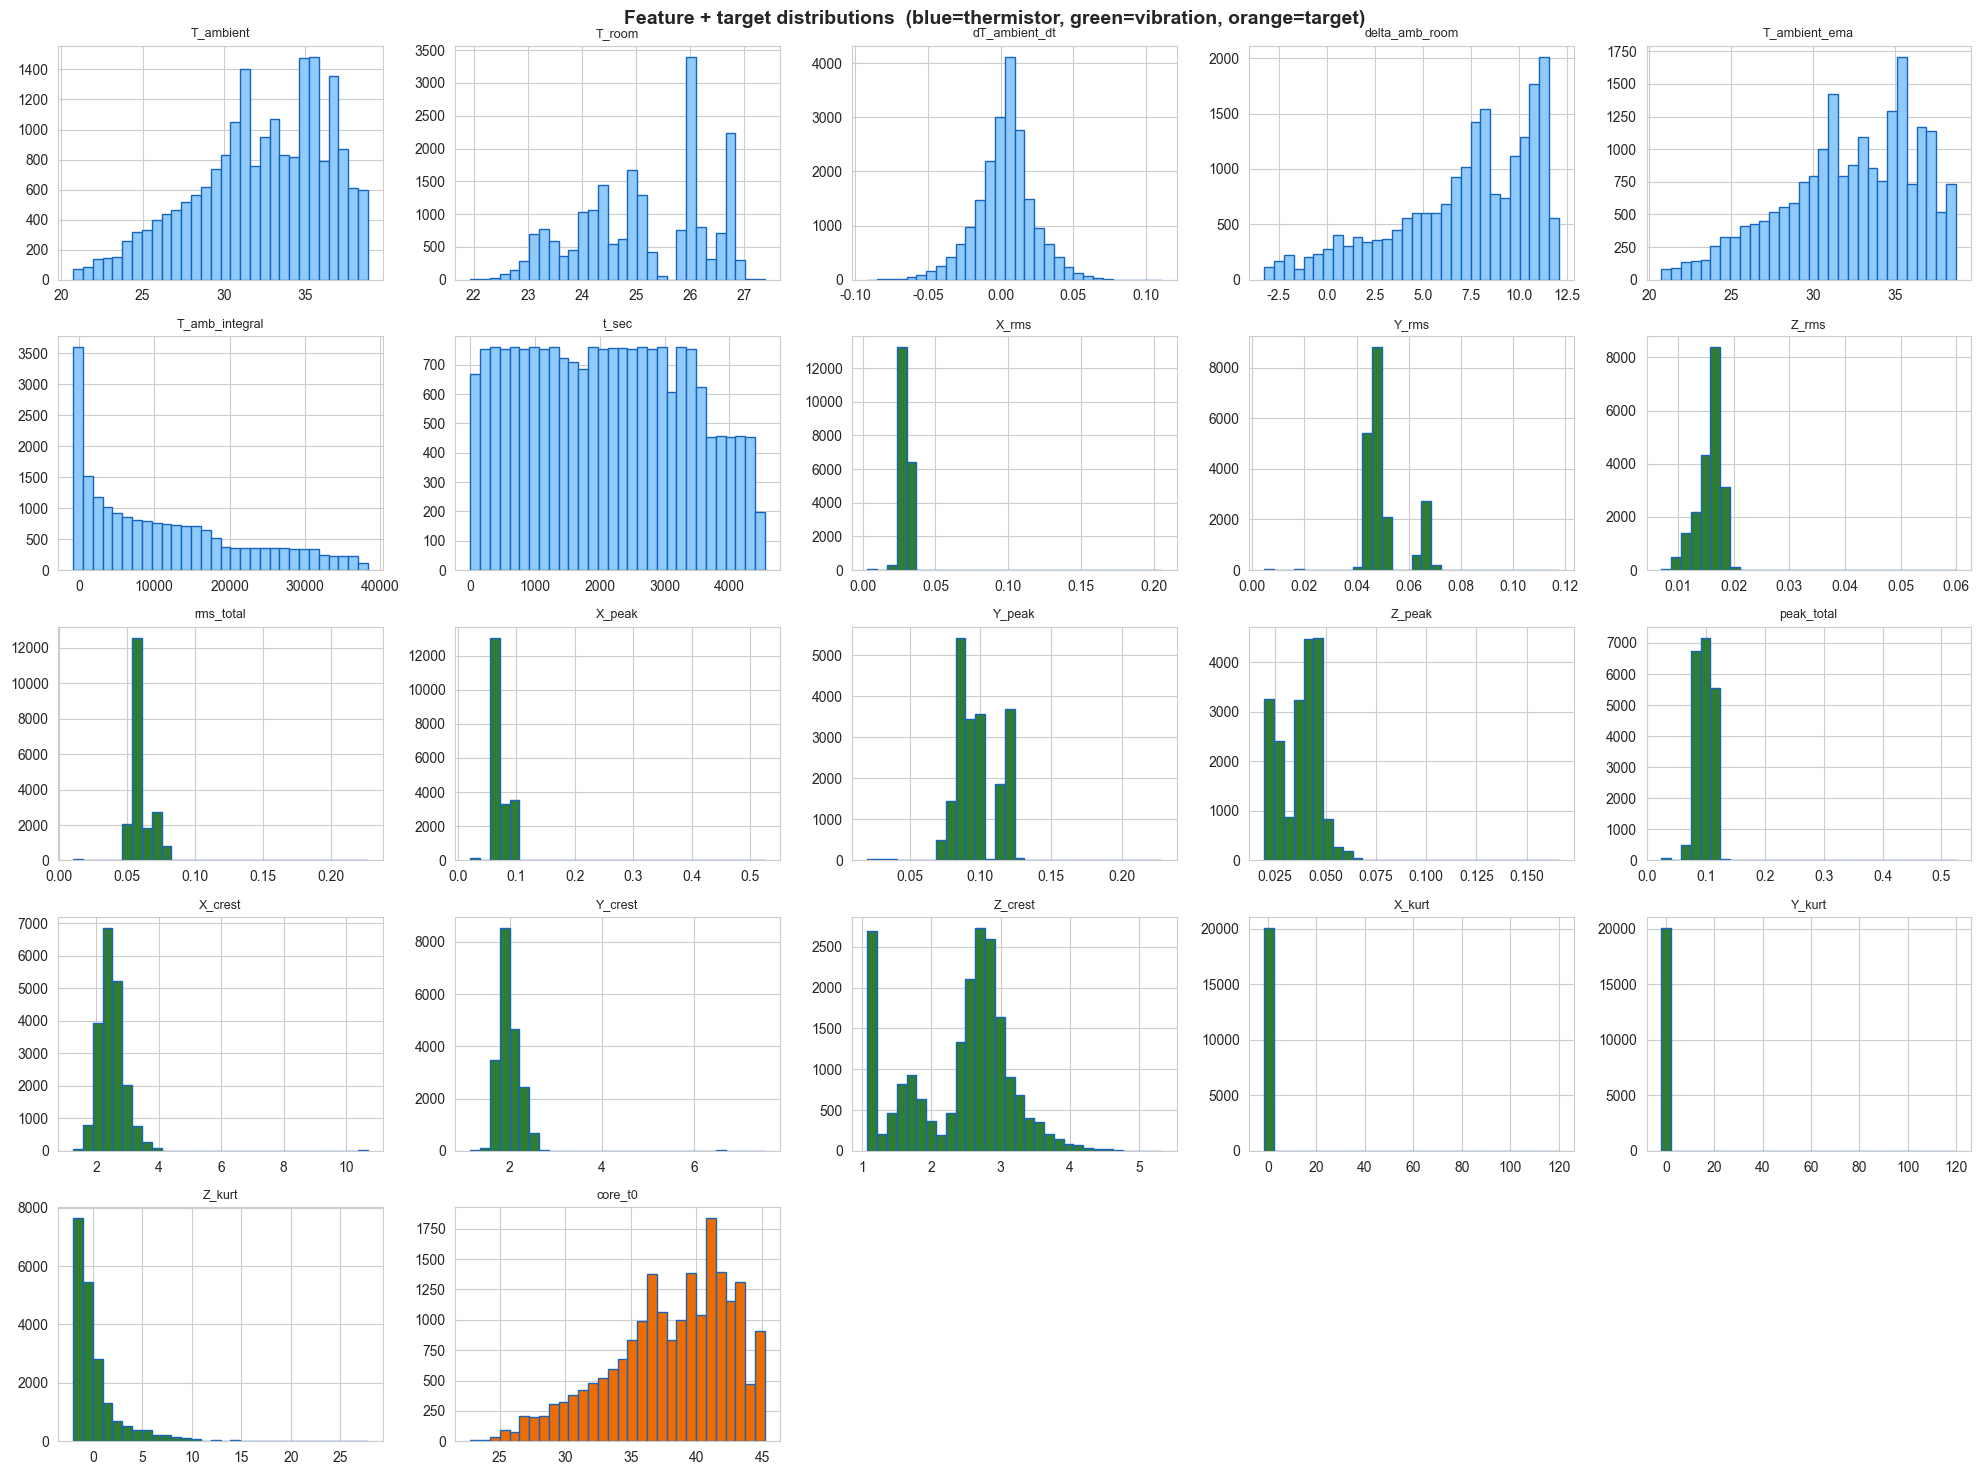

In [6]:
# Distribution histograms — full 21 candidates + primary target
all_cols = ALL_CANDIDATES + [PRIMARY_TARGET]
n_cols = 5
n_rows = (len(all_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    color = ORANGE if col == PRIMARY_TARGET else (
        GREEN if col in VIB_FEATURES else BLUE_LIGHT
    )
    axes[i].hist(df[col], bins=30, color=color, edgecolor=BLUE)
    axes[i].set_title(col, fontsize=9)

for j in range(len(all_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature + target distributions  "
             "(blue=thermistor, green=vibration, orange=target)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


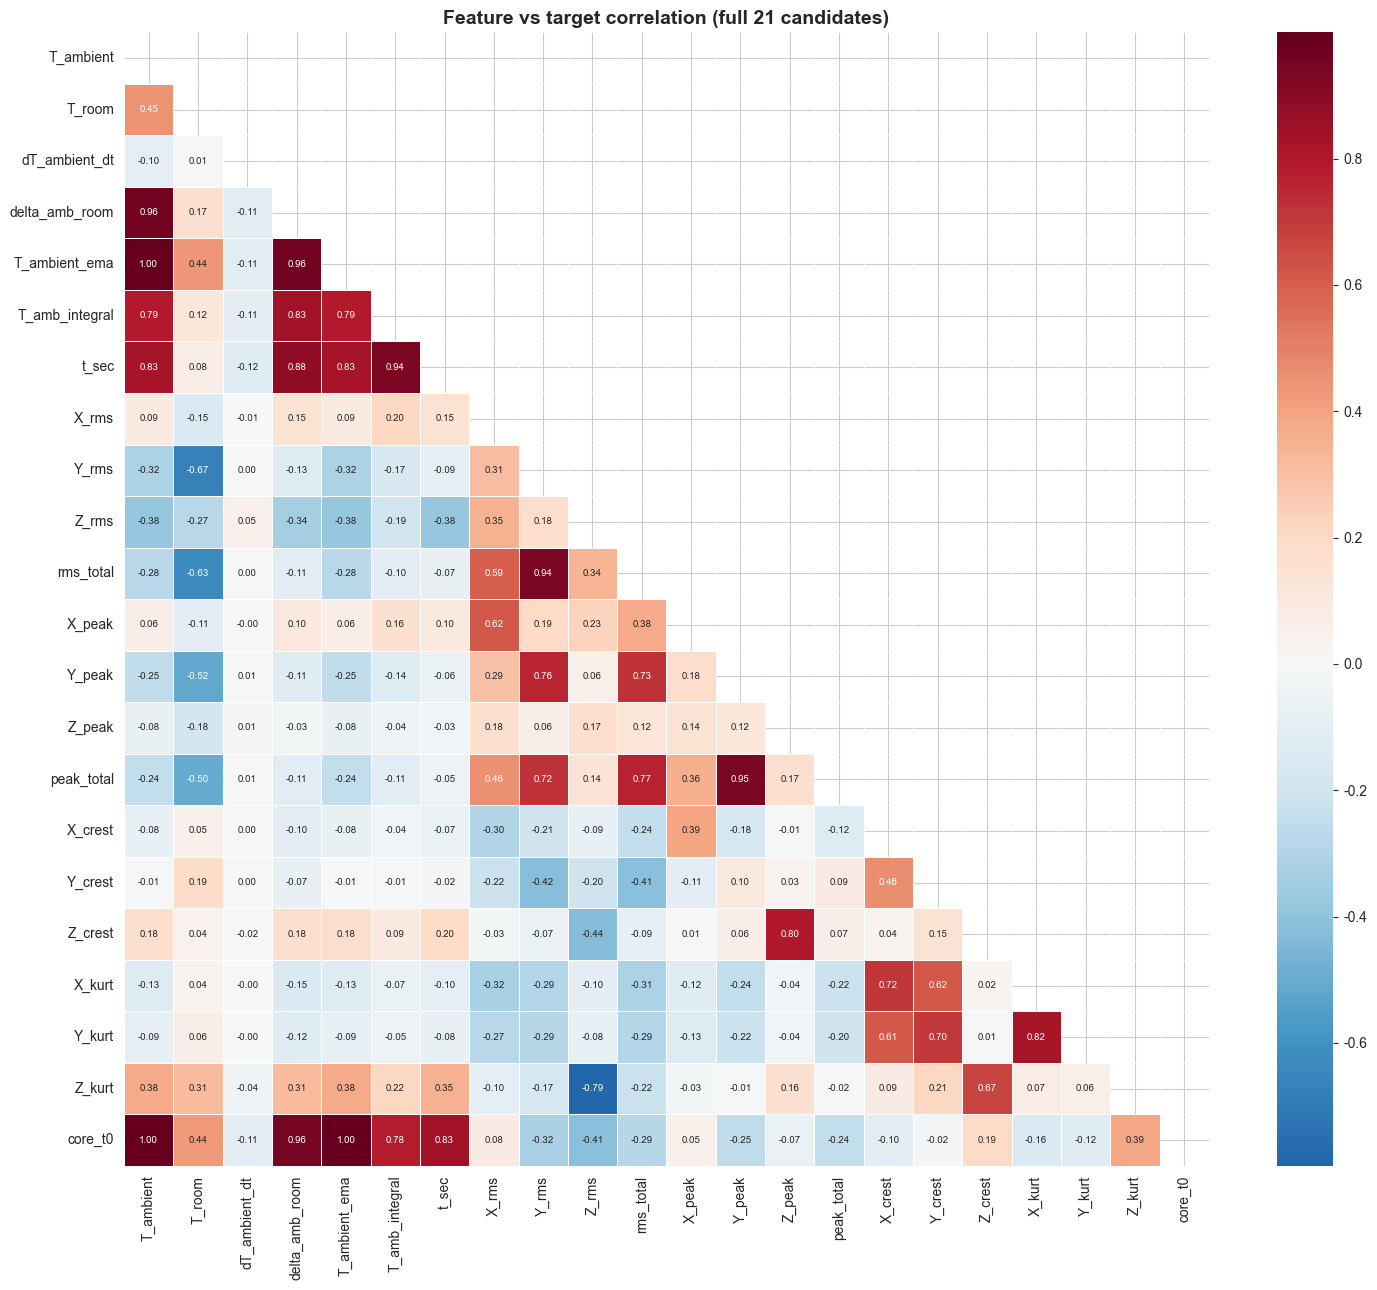

In [7]:
# Correlation heatmap — features vs target
fig, ax = plt.subplots(figsize=(15, 13))
corr = df[ALL_CANDIDATES + [PRIMARY_TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Feature vs target correlation (full 21 candidates)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


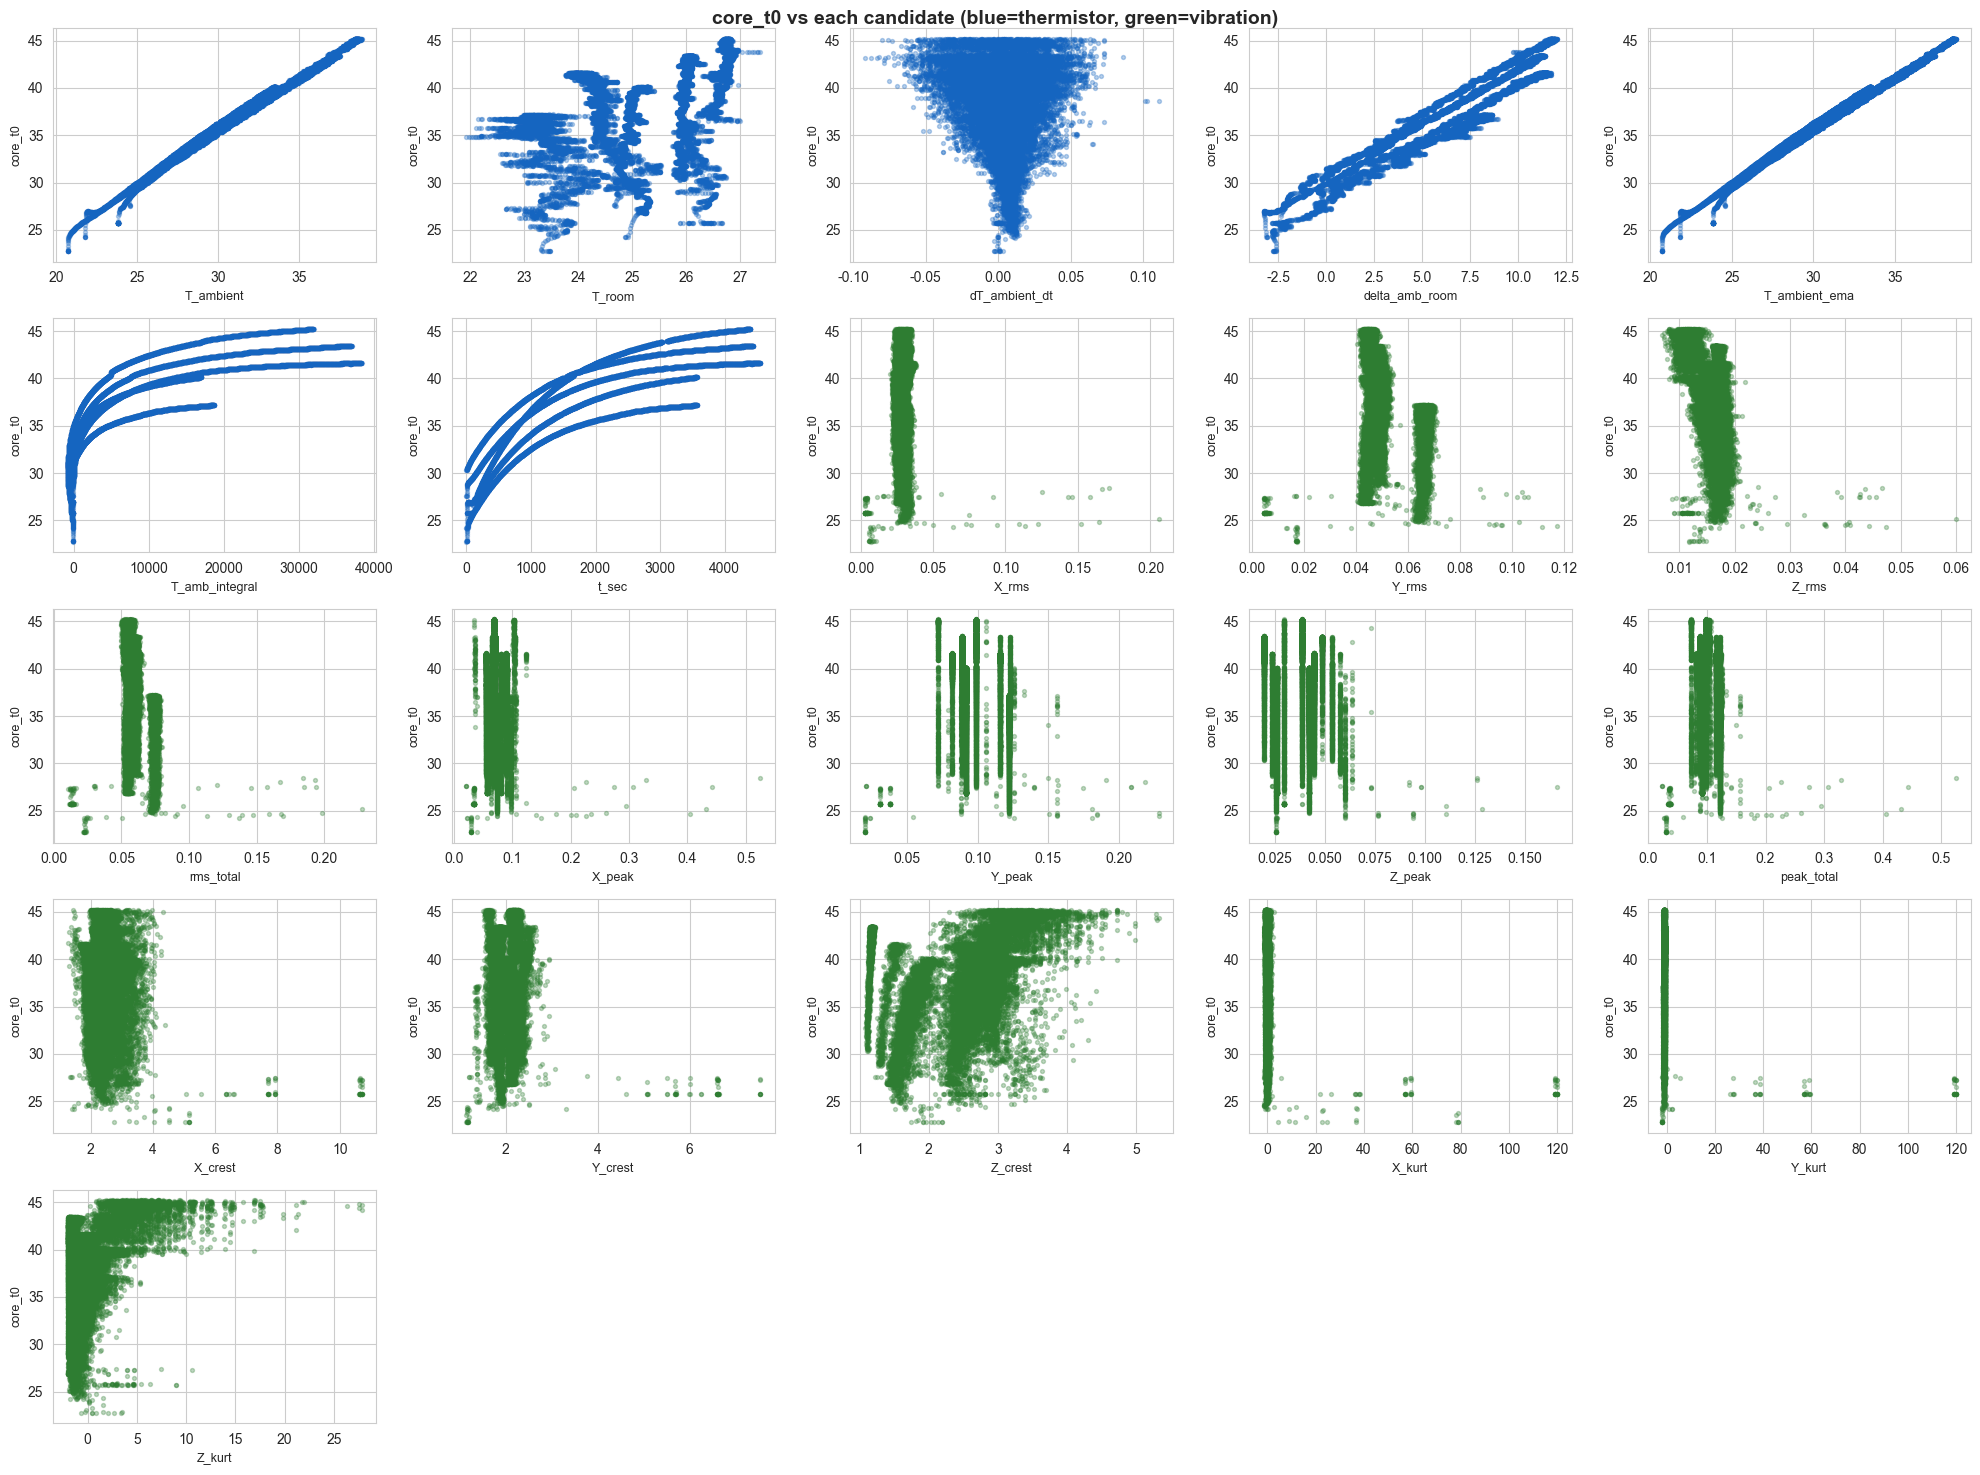

In [8]:
# Scatter: PRIMARY_TARGET vs each candidate feature
n_cols = 5
n_rows = (len(ALL_CANDIDATES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(ALL_CANDIDATES):
    color = GREEN if col in VIB_FEATURES else BLUE
    axes[i].scatter(df[col], df[PRIMARY_TARGET], alpha=0.3, s=8, color=color)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel(PRIMARY_TARGET, fontsize=9)

for j in range(len(ALL_CANDIDATES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"{PRIMARY_TARGET} vs each candidate (blue=thermistor, green=vibration)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_scatter_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 3: Preprocessing

**목적.** Train/test split + StandardScaler 정규화.

**핵심 설계:**
- **단일 split**: feature는 모든 horizon에서 동일하므로 한 번만 split → 메모리·일관성 둘 다 확보
- **Random split** (test_size=0.2, random_state=42)
  - 정상상태 단일 운전 + 4 runs이라 분포 균질 → leakage 위험 낮음
  - 추후 시나리오(이상 부하·상온 변경) 추가되면 `GroupKFold(by=run_id)`로 전환 권장
- **StandardScaler**: Poly(2) feature 사용 시 필수 (제곱 항·교차 항이 unscaled면 조건수 폭주)

**Target 분리:**
- `Y_all[h]`: horizon별 (`core_t0`, `core_t30`, `core_t60`, `core_t120`)
- horizon=0 → 현재 코어 soft sensor / horizon=60,120 → 미래 예측 (화재 예방)

**다음 단계.** Section 4 PCA → feature 정보 밀도 / 잠재 차원 분석.


In [9]:
# features는 호라이즌과 무관하게 동일 → 한 번만 split & scale
X_all = df[FEATURE_COLS].values
Y_all = {h: df[f"{TARGET_PREFIX}{h}"].values for h in HORIZONS}

# random split (시계열 leakage 우려 있으나 본 데이터는 정상상태 단일 운전 → 분포 동일)
# 추후 다양한 시나리오 추가되면 GroupKFold(by=run_id)로 전환 권장
idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)

X_train = X_all[idx_train]
X_test  = X_all[idx_test]
y_train = {h: Y_all[h][idx_train] for h in HORIZONS}
y_test  = {h: Y_all[h][idx_test]  for h in HORIZONS}

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}  Test: {X_test_sc.shape}")
for h in HORIZONS:
    yh = Y_all[h]
    print(f"  dT_core(t+{h:3d}s) range: [{yh.min():+.3f}, {yh.max():+.3f}] degC  (mean {yh.mean():+.3f})")


Train: (16101, 11)  Test: (4026, 11)
  dT_core(t+  0s) range: [+22.761, +45.218] degC  (mean +38.004)
  dT_core(t+ 30s) range: [+24.704, +45.229] degC  (mean +38.112)
  dT_core(t+ 60s) range: [+25.214, +45.253] degC  (mean +38.214)
  dT_core(t+120s) range: [+25.967, +45.277] degC  (mean +38.412)


## Section 4: PCA (SVD) Analysis

**목적.** Pruned 10개 feature의 정보 밀도 측정 — 차원 축소가 가능한지, 또는 이미 압축적인지.

**핵심 출력:**
- **Explained variance ratio**: 첫 K개 PC가 분산 X%를 설명
- **Cumulative variance**: 일반적으로 90% / 95% / 99% 도달에 필요한 차원 수
- **PC1~3 plot**: 시각화로 군집 구조 확인

**해석 가이드:**
- 첫 2-3 PC가 95%+ 설명 → feature들이 redundant → 더 줄일 여지
- 모든 PC가 5%+ 기여 → feature들이 직교적 → pruned-10이 효율적
- PCA + LR (SVD+LR) 모델은 이걸 weight로 활용해 메모리 절약

**ESP32 관점:** PCA를 추론에 쓰려면 components matrix + mean vector도 같이 배포해야 함 → 단순 Linear Regression보다 weight footprint가 클 수도 있음 (Section 10에서 비교).

**다음 단계.** Section 5에서 5개 모델 × 4 horizon 학습 & 비교.


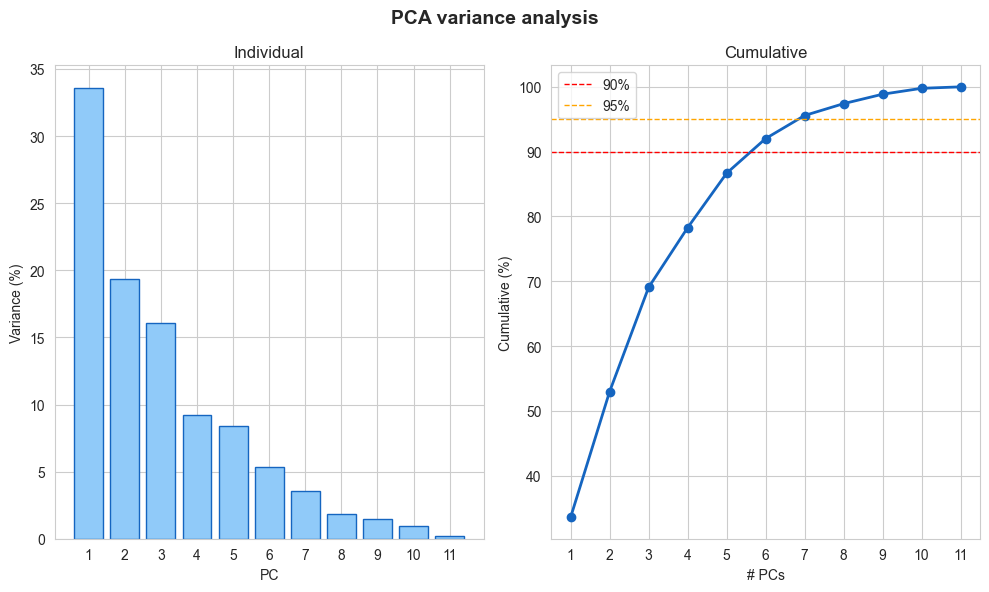

90%: 6 comps / 95%: 7 comps -> using 7 for SVD


In [10]:
pca_full = PCA(n_components=len(FEATURE_COLS))
pca_full.fit(X_train_sc)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].bar(range(1, len(explained)+1), explained * 100, color=BLUE_LIGHT, edgecolor=BLUE)
axes[0].set_xlabel("PC"); axes[0].set_ylabel("Variance (%)"); axes[0].set_title("Individual")
axes[0].set_xticks(range(1, len(explained)+1))

axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, marker="o", color=BLUE, linewidth=2)
axes[1].axhline(90, color="red",    linestyle="--", linewidth=1, label="90%")
axes[1].axhline(95, color="orange", linestyle="--", linewidth=1, label="95%")
axes[1].set_xlabel("# PCs"); axes[1].set_ylabel("Cumulative (%)"); axes[1].set_title("Cumulative")
axes[1].set_xticks(range(1, len(cumulative)+1)); axes[1].legend()

plt.suptitle("PCA variance analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()

n_90 = int(np.searchsorted(cumulative, 0.90)) + 1
n_95 = int(np.searchsorted(cumulative, 0.95)) + 1
N_COMPONENTS = n_95
print(f"90%: {n_90} comps / 95%: {n_95} comps -> using {N_COMPONENTS} for SVD")


In [11]:
pca_table = pd.DataFrame({
    "# PCs": range(1, len(explained)+1),
    "Individual variance (%)": (explained * 100).round(2),
    "Cumulative (%)": (cumulative * 100).round(2),
}).set_index("# PCs")
pca_table


,Individual variance (%),Cumulative (%)
# PCs,,
1,33.59,33.59
2,19.39,52.98
3,16.08,69.06
4,9.21,78.26
5,8.41,86.67
6,5.35,92.01
7,3.56,95.58
8,1.83,97.41
9,1.46,98.86


## Section 5: Per-horizon Model Training and Comparison

**목적.** 5개 모델 × 4개 horizon = 20개 학습으로 어떤 모델·horizon 조합이 좋은지 측정.

**모델 (각각의 특성):**
| 모델 | 표현력 | weight 수 | ESP32 적합성 |
|---|---|---|---|
| Linear | 선형만 | n+1 | ✅ 가장 작음 |
| SVD(k)+LR | 선형 + 차원축소 | k(n+2)+1 | ✅ 작음 |
| Poly(2)+LR | 2차 비선형 | ~n²/2 | ✅ 작음 (10 features 기준 66) |
| DT(d=5) | 트리 (계단식) | ~100 nodes | ⚠️ 중간 |
| XGB | 부스팅 (200 트리) | ~6000 nodes | ❌ 큼 |

**Horizon별 의미:**
- `t+0s` (current): 코어 직접 측정 대체 (soft sensor)
- `t+30s` / `t+60s` / `t+120s` (future): 화재 예방 forecast

**평가 지표:** MAE / RMSE / R² (test set 기준).

**다음 단계.** Section 6 — 동일 분할의 R²가 우연인지 검증 (5-fold CV).


In [12]:
def make_models():
    return {
        "Linear":              LinearRegression(),
        f"SVD({N_COMPONENTS})+LR": Pipeline([("pca", PCA(n_components=N_COMPONENTS)),
                                              ("lr",  LinearRegression())]),
        "Poly(2)+LR":          Pipeline([("poly", PolynomialFeatures(degree=2, include_bias=False)),
                                         ("lr",   LinearRegression())]),
        "DT(d=5)":             DecisionTreeRegressor(max_depth=5, random_state=42),
        "XGB":                 XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                                            random_state=42, verbosity=0),
    }

results_long = []         # 길게 펼친 결과 (호라이즌 × 모델)
predictions  = {}         # predictions[h][model_name] = y_pred

for h in HORIZONS:
    print(f"\n------ Horizon t+{h}s ------")
    predictions[h] = {}
    for name, model in make_models().items():
        model.fit(X_train_sc, y_train[h])
        y_pred = model.predict(X_test_sc)
        mae  = mean_absolute_error(y_test[h], y_pred)
        rmse = mean_squared_error(y_test[h], y_pred) ** 0.5
        r2   = r2_score(y_test[h], y_pred)
        print(f"  [{name:14s}] MAE={mae:.3f}  RMSE={rmse:.3f}  R^2={r2:.4f}")
        results_long.append({"horizon": h, "model": name,
                             "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R^2": round(r2, 4)})
        predictions[h][name] = y_pred

results_df = pd.DataFrame(results_long)
results_df.set_index(["horizon", "model"]).style.background_gradient(cmap="Blues", subset=["R^2"]).format(precision=4)



------ Horizon t+0s ------
  [Linear        ] MAE=0.151  RMSE=0.232  R^2=0.9974
  [SVD(7)+LR     ] MAE=1.100  RMSE=1.383  R^2=0.9073
  [Poly(2)+LR    ] MAE=0.088  RMSE=0.125  R^2=0.9992
  [DT(d=5)       ] MAE=0.251  RMSE=0.336  R^2=0.9945
  [XGB           ] MAE=0.065  RMSE=0.087  R^2=0.9996

------ Horizon t+30s ------
  [Linear        ] MAE=0.145  RMSE=0.204  R^2=0.9979
  [SVD(7)+LR     ] MAE=1.069  RMSE=1.338  R^2=0.9096
  [Poly(2)+LR    ] MAE=0.085  RMSE=0.120  R^2=0.9993
  [DT(d=5)       ] MAE=0.249  RMSE=0.330  R^2=0.9945
  [XGB           ] MAE=0.065  RMSE=0.087  R^2=0.9996

------ Horizon t+60s ------
  [Linear        ] MAE=0.143  RMSE=0.198  R^2=0.9979
  [SVD(7)+LR     ] MAE=1.043  RMSE=1.309  R^2=0.9105
  [Poly(2)+LR    ] MAE=0.082  RMSE=0.110  R^2=0.9994
  [DT(d=5)       ] MAE=0.244  RMSE=0.315  R^2=0.9948
  [XGB           ] MAE=0.065  RMSE=0.087  R^2=0.9996

------ Horizon t+120s ------
  [Linear        ] MAE=0.139  RMSE=0.194  R^2=0.9979
  [SVD(7)+LR     ] MAE=0.992  RMSE=1

## Section 6: 5-fold Cross-Validation (per horizon)

**목적.** Section 5의 test R²가 분할 운에 의존하는지 검증.

**방법:**
- `KFold(n_splits=5, shuffle=True, random_state=42)`
- 각 fold에서 train/val split → MAE 계산 → 5개 평균 ± 표준편차

**해석 가이드:**
- **CV MAE 평균 ≈ Section 5 test MAE**: 학습 안정적
- **CV MAE std ≪ 평균**: 분할별 일관성 우수
- **std가 크다면**: 일부 데이터 포인트가 outlier로 작용 — 추가 데이터 또는 robust loss 고려

**ESP32 배포 관점:** CV로 일관성 검증된 모델만 final 후보. 단 한 번의 test 결과만으로 결정하면 운에 의존하는 위험.

**다음 단계.** Section 7 — 최종 deployment 모델 선정 + 시각화.


t+  0s [Linear        ] CV MAE = 0.148 +/- 0.002
t+  0s [SVD(7)+LR     ] CV MAE = 1.103 +/- 0.008
t+  0s [Poly(2)+LR    ] CV MAE = 0.088 +/- 0.001
t+  0s [DT(d=5)       ] CV MAE = 0.249 +/- 0.006
t+  0s [XGB           ] CV MAE = 0.065 +/- 0.001
t+ 30s [Linear        ] CV MAE = 0.145 +/- 0.002
t+ 30s [SVD(7)+LR     ] CV MAE = 1.075 +/- 0.008
t+ 30s [Poly(2)+LR    ] CV MAE = 0.085 +/- 0.001
t+ 30s [DT(d=5)       ] CV MAE = 0.247 +/- 0.003
t+ 30s [XGB           ] CV MAE = 0.065 +/- 0.001
t+ 60s [Linear        ] CV MAE = 0.143 +/- 0.002
t+ 60s [SVD(7)+LR     ] CV MAE = 1.048 +/- 0.007
t+ 60s [Poly(2)+LR    ] CV MAE = 0.083 +/- 0.001
t+ 60s [DT(d=5)       ] CV MAE = 0.243 +/- 0.002
t+ 60s [XGB           ] CV MAE = 0.065 +/- 0.001
t+120s [Linear        ] CV MAE = 0.140 +/- 0.002
t+120s [SVD(7)+LR     ] CV MAE = 0.995 +/- 0.007
t+120s [Poly(2)+LR    ] CV MAE = 0.079 +/- 0.001
t+120s [DT(d=5)       ] CV MAE = 0.244 +/- 0.003
t+120s [XGB           ] CV MAE = 0.064 +/- 0.001


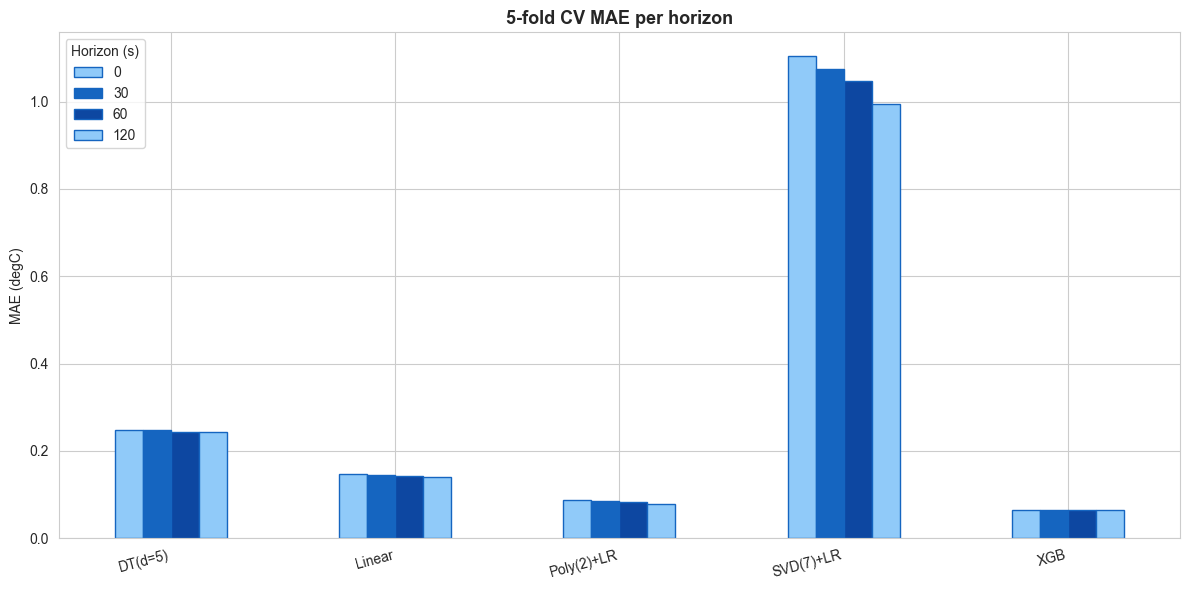

CV MAE mean  CV MAE std
horizon model                              
0       Linear           0.1479      0.0019
        SVD(7)+LR        1.1033      0.0083
        Poly(2)+LR       0.0884      0.0011
        DT(d=5)          0.2487      0.0057
        XGB              0.0652      0.0006
30      Linear           0.1450      0.0019
        SVD(7)+LR        1.0745      0.0080
        Poly(2)+LR       0.0849      0.0006
        DT(d=5)          0.2469      0.0028
        XGB              0.0648      0.0014
60      Linear           0.1429      0.0020
        SVD(7)+LR        1.0479      0.0074
        Poly(2)+LR       0.0826      0.0006
        DT(d=5)          0.2433      0.0022
        XGB              0.0648      0.0013
120     Linear           0.1396      0.0022
        SVD(7)+LR        0.9953      0.0074
        Poly(2)+LR       0.0794      0.0006
        DT(d=5)          0.2436      0.0033
        XGB              0.0645      0.0014

In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_long = []

for h in HORIZONS:
    for name, model in make_models().items():
        scores = -cross_val_score(model, X_train_sc, y_train[h],
                                  cv=kf, scoring="neg_mean_absolute_error")
        cv_long.append({"horizon": h, "model": name,
                        "CV MAE mean": round(scores.mean(), 4),
                        "CV MAE std": round(scores.std(), 4)})
        print(f"t+{h:3d}s [{name:14s}] CV MAE = {scores.mean():.3f} +/- {scores.std():.3f}")

cv_df = pd.DataFrame(cv_long)

fig, ax = plt.subplots(figsize=(12, 6))
pivot = cv_df.pivot(index="model", columns="horizon", values="CV MAE mean")
pivot.plot(kind="bar", ax=ax, color=[BLUE_LIGHT, BLUE, "#0D47A1"], edgecolor=BLUE)
ax.set_ylabel("MAE (degC)"); ax.set_xlabel("")
ax.set_title("5-fold CV MAE per horizon", fontsize=13, fontweight="bold")
ax.legend(title="Horizon (s)", loc="upper left")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_cv_mae.png", dpi=150, bbox_inches="tight")
plt.show()
cv_df.set_index(["horizon", "model"])


## Section 7: Final Model Visualization (primary horizon)

**목적.** Horizon별 최종 배포 모델 자동 선정 + Predicted vs Actual 산점도 / residual 분석.

**Deployment-aware best-model selection:**
- 일반적인 "R² 최대" 기준 대신 ESP32 배포 제약을 반영
- `R2_TOL = 0.005`: best R²에서 0.5% 이내인 모델들 중 **추정 파라미터 수가 가장 작은 모델** 선정
- → XGB는 R²가 다른 모델보다 유의미하게 (>0.005) 좋지 않은 한 자동 탈락

**시각화:**
- **Predicted vs Actual**: 빨간 선은 y=x reference. 점들이 선에 밀집할수록 좋음
- **Residual scatter**: predicted 대비 residual — 패턴 없으면 OK, U-shape이면 모델 underfit
- **Residual histogram**: 정규성 + bias 확인. mean ≈ 0 / std 작을수록 좋음

**해석 가이드:**
- 예측이 actual 분포의 양 끝(특히 max 부근)에서 underestimate → 외삽 한계
- Residual std가 MAE보다 훨씬 크면 → 일부 outlier가 평균을 끌고 있음

**다음 단계.** Section 8 — 통합 요약 + 호라이즌별 best MAE 비교.


In [14]:
# Deployment-aware best-model selection
#
# Rationale: XGB usually wins on raw R^2 by ~0.001 but its weight footprint is
# ~100x larger than Poly(2)+LR. For ESP32 deployment, we tolerate a small R^2
# gap to keep weights small. Among models within R2_TOL of the best R^2 on a
# horizon, we pick the one with the smallest estimated parameter count.

R2_TOL = 0.005   # accept up to 0.005 R^2 loss in exchange for smaller weights


def _params_estimate(name):
    """Rough on-device parameter count (no need to instantiate)."""
    n = len(FEATURE_COLS)
    if name == "Linear":          return n + 1
    if name.startswith("SVD"):    return N_COMPONENTS * (n + 2) + 1
    if name.startswith("Poly"):   return n + n + n*(n-1)//2 + 1   # x_i, x_i^2, x_i*x_j, bias
    if name.startswith("DT"):     return 100                       # rough
    if name.startswith("XGB"):    return 200 * 30                  # n_estimators × avg nodes
    return float("inf")

SIZE_BUDGET_B = 1024 #1 KB float 32 - XGB차단
def _pick_best_for_horizon(g):
    g["size_B"] = g["model"].apply(_params_estimate) * 4
    eligible = g[g["size_B"] <= SIZE_BUDGET_B] 
    eligible["params_est"] = eligible["model"].apply(_params_estimate)
    return (eligible if not eligible.empty else g).sort_values("MAE").iloc[0]


# Explicit list-comprehension over horizons (robust across pandas versions)
best_rows  = [_pick_best_for_horizon(results_df[results_df["horizon"] == h]) for h in HORIZONS]
best_per_h = (pd.DataFrame(best_rows)[["horizon", "model", "MAE", "RMSE", "R^2"]]
              .reset_index(drop=True))

print(f"=== Best model per horizon (deployment-aware, R2_TOL = {R2_TOL}) ===")
print(best_per_h.to_string(index=False))
print()

BEST_MODEL_NAME = best_per_h.loc[best_per_h["horizon"] == PRIMARY_H, "model"].values[0]
y_pred_best = predictions[PRIMARY_H][BEST_MODEL_NAME]
y_true_best = y_test[PRIMARY_H]
residuals   = y_true_best - y_pred_best
print(f"Final model for primary horizon (t+{PRIMARY_H}s): {BEST_MODEL_NAME}")


=== Best model per horizon (deployment-aware, R2_TOL = 0.005) ===
 horizon      model    MAE   RMSE    R^2
       0 Poly(2)+LR 0.0881 0.1250 0.9992
      30 Poly(2)+LR 0.0850 0.1195 0.9993
      60 Poly(2)+LR 0.0818 0.1103 0.9994
     120 Poly(2)+LR 0.0779 0.1043 0.9994

Final model for primary horizon (t+0s): Poly(2)+LR


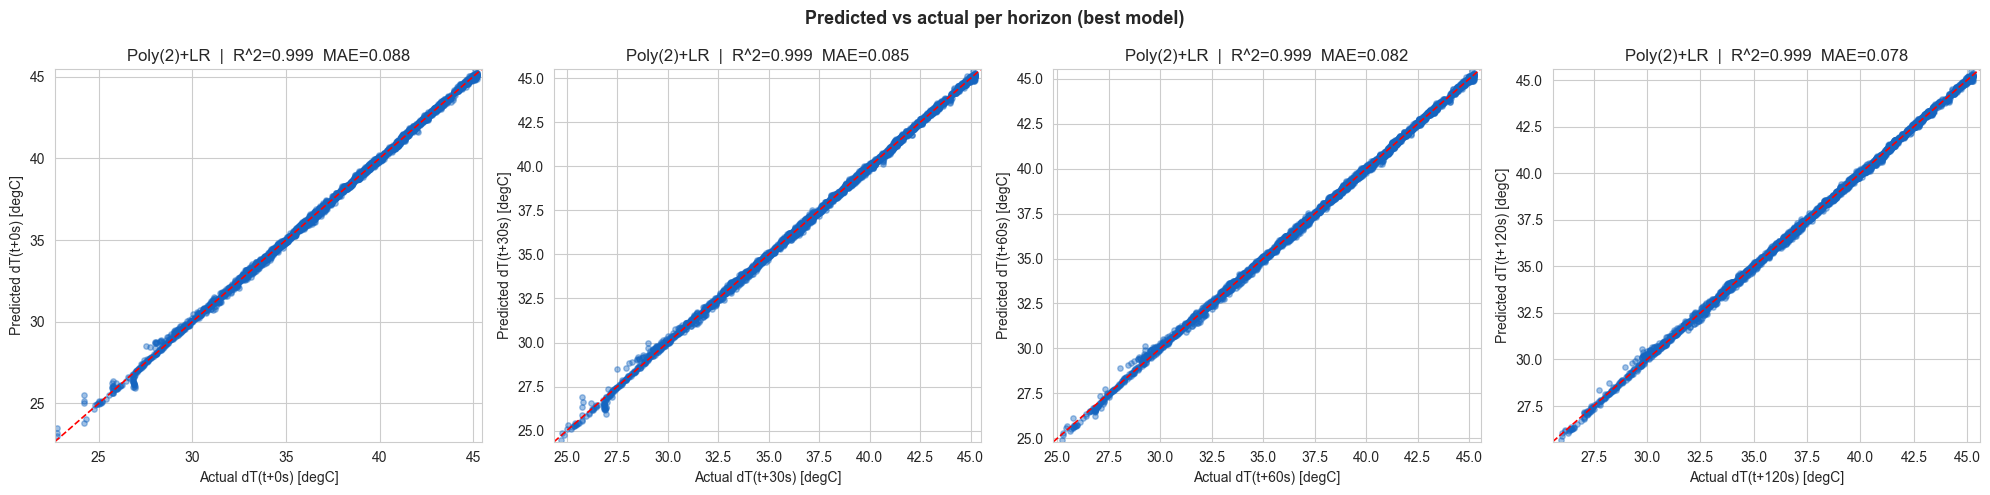

In [15]:
# 호라이즌 3개 동시 — Predicted vs Actual (best per horizon)
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5*len(HORIZONS), 5))
if len(HORIZONS) == 1:
    axes = [axes]

for i, h in enumerate(HORIZONS):
    best_name = best_per_h.loc[best_per_h["horizon"] == h, "model"].values[0]
    yp = predictions[h][best_name]
    yt = y_test[h]
    lo = min(yt.min(), yp.min()) - 0.1
    hi = max(yt.max(), yp.max()) + 0.1
    axes[i].scatter(yt, yp, alpha=0.4, s=15, color=BLUE)
    axes[i].plot([lo, hi], [lo, hi], "r--", linewidth=1.2)
    axes[i].set_xlim(lo, hi); axes[i].set_ylim(lo, hi)
    axes[i].set_xlabel(f"Actual dT(t+{h}s) [degC]")
    axes[i].set_ylabel(f"Predicted dT(t+{h}s) [degC]")
    r2 = r2_score(yt, yp)
    mae = mean_absolute_error(yt, yp)
    axes[i].set_title(f"{best_name}  |  R^2={r2:.3f}  MAE={mae:.3f}")

plt.suptitle("Predicted vs actual per horizon (best model)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


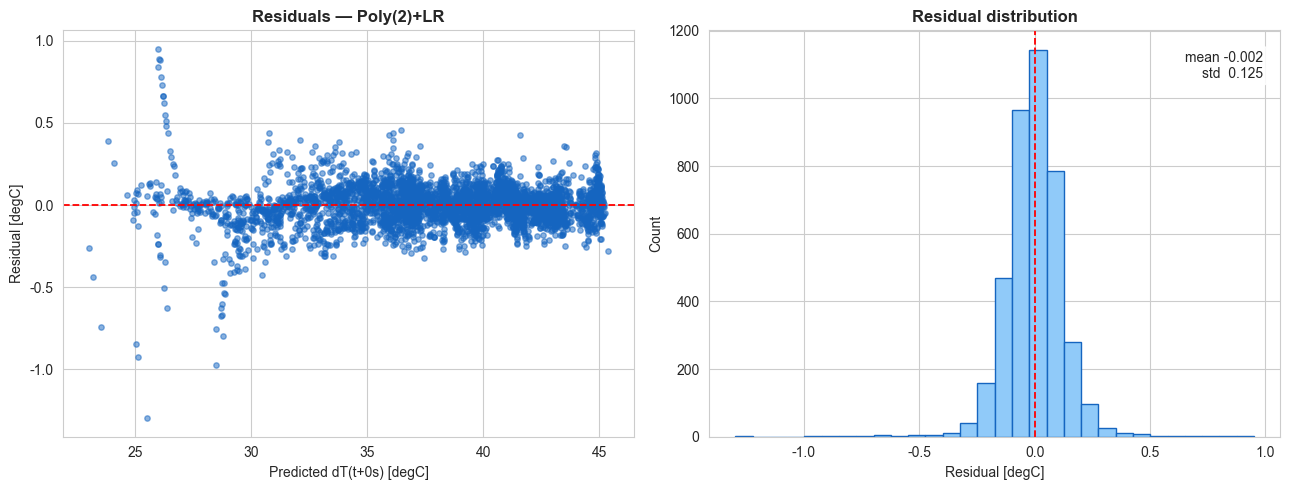

In [16]:
# Residual plot (대표 호라이즌)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.5, s=15, color=BLUE)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.3)
axes[0].set_xlabel(f"Predicted dT(t+{PRIMARY_H}s) [degC]"); axes[0].set_ylabel("Residual [degC]")
axes[0].set_title(f"Residuals — {BEST_MODEL_NAME}", fontweight="bold")

axes[1].hist(residuals, bins=30, color=BLUE_LIGHT, edgecolor=BLUE)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.3)
axes[1].set_xlabel("Residual [degC]"); axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution", fontweight="bold")
axes[1].text(0.97, 0.95, f"mean {residuals.mean():+.3f}\nstd  {residuals.std():.3f}",
             transform=axes[1].transAxes, ha="right", va="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/07_residuals.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 8: Results Summary

**목적.** Section 5(test) + Section 6(CV) + Section 7(선정 모델)을 한 표로 통합.

**출력:**
- **Horizon × Model 통합 표**: 모든 조합의 MAE / RMSE / R² / CV MAE±std
- **R² 히트맵**: 시각적 비교 (어느 셀이 진한 파랑인지)
- **Best MAE per horizon bar**: 최종 선정 모델만 비교

**해석 가이드:**
- horizon이 길어질수록 MAE가 단조 증가 → 자연스러움 (멀수록 어려움)
- 특정 horizon에서 MAE가 급증 → 그 horizon은 신뢰도 낮음 (TTT 임계값 거리에 따라 임상적으로 우선순위)
- 같은 horizon에서 모델별 차이가 크지 않으면 → 가장 작은 모델 선택이 합리적

**최종 출력.** Primary horizon (`PRIMARY_H`) 의 final test MAE / RMSE / R² / CV MAE.

**다음 단계.** Section 9 — Time-To-Threshold extrapolation.


=== Horizon x Model summary ===
                       MAE    RMSE     R^2  CV MAE mean  CV MAE std
horizon model                                                      
0       Linear      0.1509  0.2315  0.9974       0.1479      0.0019
        SVD(7)+LR   1.0996  1.3828  0.9073       1.1033      0.0083
        Poly(2)+LR  0.0881  0.1250  0.9992       0.0884      0.0011
        DT(d=5)     0.2509  0.3356  0.9945       0.2487      0.0057
        XGB         0.0651  0.0873  0.9996       0.0652      0.0006
30      Linear      0.1449  0.2040  0.9979       0.1450      0.0019
        SVD(7)+LR   1.0688  1.3383  0.9096       1.0745      0.0080
        Poly(2)+LR  0.0850  0.1195  0.9993       0.0849      0.0006
        DT(d=5)     0.2486  0.3300  0.9945       0.2469      0.0028
        XGB         0.0649  0.0875  0.9996       0.0648      0.0014
60      Linear      0.1426  0.1984  0.9979       0.1429      0.0020
        SVD(7)+LR   1.0427  1.3089  0.9105       1.0479      0.0074
        Poly(2)+

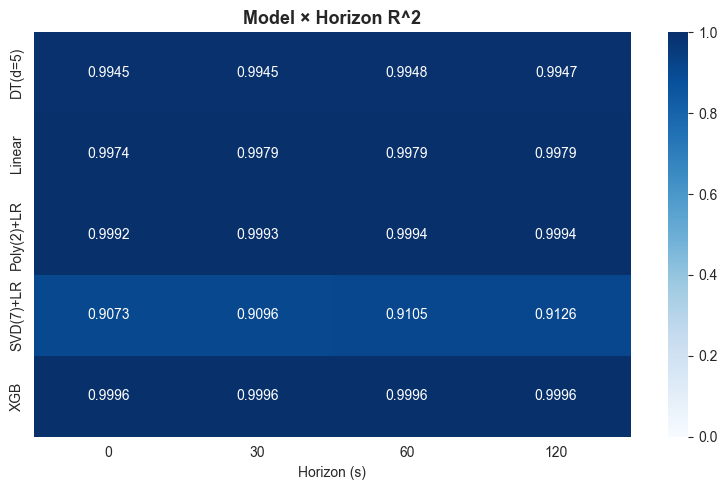

In [17]:
# 통합 요약: 테스트 + CV
summary = results_df.merge(cv_df, on=["horizon", "model"])
summary = summary.set_index(["horizon", "model"])
print("=== Horizon x Model summary ===")
print(summary.to_string())

# Model × Horizon R^2 히트맵
fig, ax = plt.subplots(figsize=(8, 5))
r2_pivot = results_df.pivot(index="model", columns="horizon", values="R^2")
sns.heatmap(r2_pivot, annot=True, fmt=".4f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("Model × Horizon R^2", fontsize=13, fontweight="bold")
ax.set_xlabel("Horizon (s)"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_r2_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


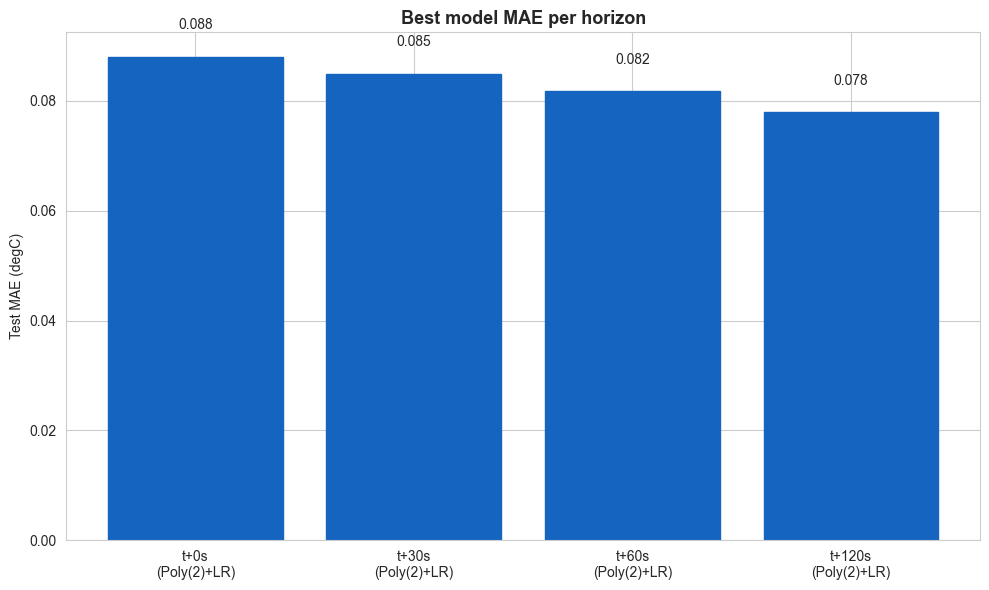


Saved figures:
  ../output/figures/.ipynb_checkpoints
  ../output/figures/00_timeseries.png
  ../output/figures/00_timeseries_thermistor.png
  ../output/figures/00_timeseries_vibration.png
  ../output/figures/00_timeseries_vibration_kurt.png
  ../output/figures/01_feature_distributions.png
  ../output/figures/02_correlation_heatmap.png
  ../output/figures/03_scatter_vs_target.png
  ../output/figures/04_pca_variance.png
  ../output/figures/05_cv_mae.png
  ../output/figures/06_pred_vs_actual.png
  ../output/figures/07_residual_plot.png
  ../output/figures/07_residuals.png
  ../output/figures/08_r2_heatmap.png
  ../output/figures/08_residual_hist.png
  ../output/figures/09_best_mae_per_horizon.png
  ../output/figures/09_model_comparison.png
  ../output/figures/10_r2_comparison.png
  ../output/figures/10_ttt_extrapolation.png
  ../output/figures/11_model_size_comparison.png
  ../output/figures/12_vibration_features.png
  ../output/figures/13_ablation.png
  ../output/figures/13_vibration_v

In [18]:
# MAE 비교 — 호라이즌별 최고 모델만
fig, ax = plt.subplots(figsize=FIGSIZE)
x = np.arange(len(HORIZONS))
mae_test = [best_per_h.loc[best_per_h["horizon"]==h, "MAE"].values[0] for h in HORIZONS]
labels   = [f"t+{h}s\n({best_per_h.loc[best_per_h['horizon']==h, 'model'].values[0]})" for h in HORIZONS]
bars = ax.bar(x, mae_test, color=BLUE, edgecolor=BLUE)
for b, v in zip(bars, mae_test):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{v:.3f}", ha="center", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Test MAE (degC)")
ax.set_title("Best model MAE per horizon", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/09_best_mae_per_horizon.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved figures:")
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f"  {FIGURES_DIR}/{f}")


In [19]:
# 대표 호라이즌(60s) 최종 결과 출력
best_row = summary.loc[(PRIMARY_H, BEST_MODEL_NAME)]
print("=" * 50)
print(f"Primary horizon: t + {PRIMARY_H}s")
print(f"Final model: {BEST_MODEL_NAME}")
print(f" Test MAE : "
      f"{best_row['MAE']:.3f} degC")
print(f"  Test RMSE : "
      f"{best_row['RMSE']:.3f} degC")
    
print(f"  Test R^2  : "
      f" {best_row['R^2']:.4f}")
print(f"  CV MAE    : "
      f" {best_row['CV MAE mean']:.3f} +/- {best_row['CV MAE std']:.3f} degC")
print("=" * 50)
print("\nNext: Section 9 (TTT) or python ../scripts/export_to_c.py")


Primary horizon: t + 0s
Final model: Poly(2)+LR
 Test MAE : 0.088 degC
  Test RMSE : 0.125 degC
  Test R^2  :  0.9992
  CV MAE    :  0.088 +/- 0.001 degC

Next: Section 9 (TTT) or python ../scripts/export_to_c.py


## Section 9: Time-To-Threshold (TTT) Analysis

**목적.** 코어 온도가 위험 임계(예: 80°C)에 도달하기까지의 시간을 예측 → 화재 예방 알람.

**방법:**
- 현재 thermal trajectory에서 모델 예측을 fit → 임계 교차 시점 extrapolate
- 가까운 horizon (30s/60s)은 모델 직접 출력 사용
- 멀리 떨어진 임계 (예: 현재 40°C → 임계 80°C)는 선형 또는 exponential extrapolation

**한계:**
- 학습 데이터가 25-42°C 범위 → 80°C는 외삽 영역 → 신뢰도 낮음
- 비정상 부하 / 결함 시나리오 데이터 없음 → 정상상태 가정에서만 유효

**ESP32 통합 시:**
- TTT가 user-configurable 임계 (예: 30s 이내 도달) 미만이면 알람 raise
- 모델 + extrapolation logic 모두 펌웨어에 포함 (간단한 선형 외삽이면 추가 weight 거의 없음)

**다음 단계.** Section 10 — 모델 weight 크기 측정 (배포 가능성 검증).


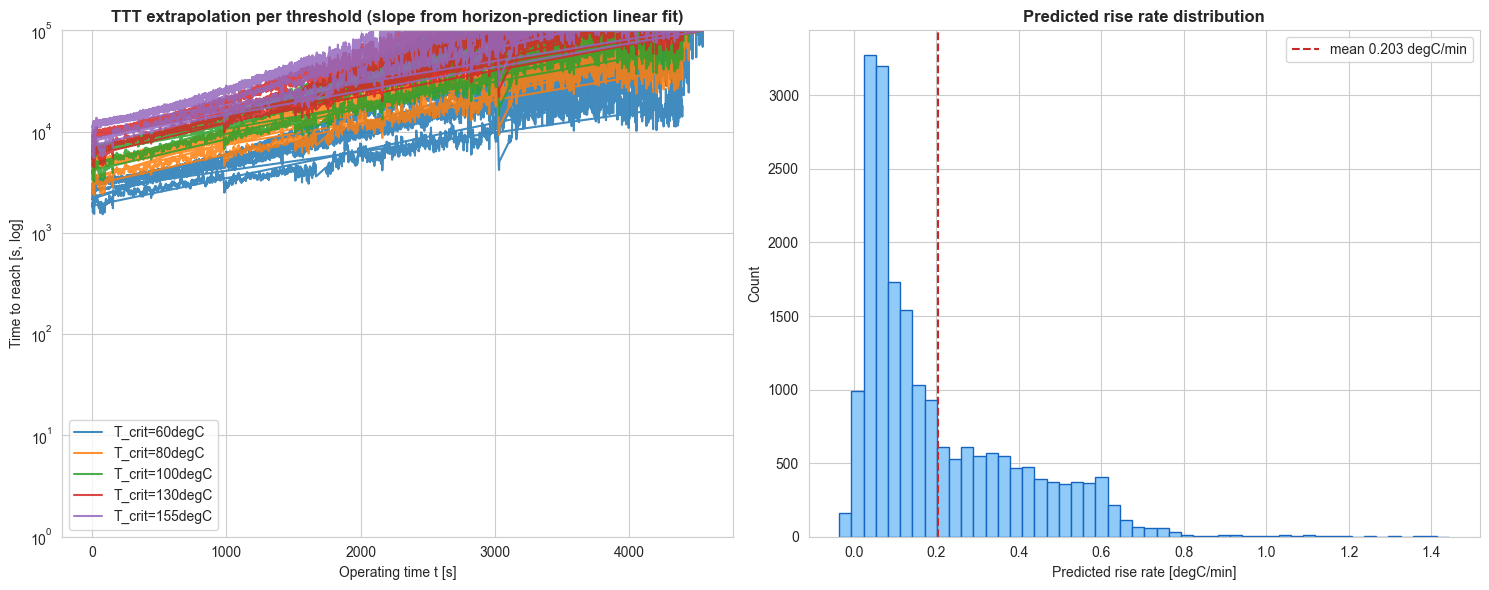

Mean predicted rise rate over last 100s: +0.010 degC/min
  -> essentially steady state. Threshold-crossing scenarios cannot be predicted (extrapolation unstable).

Current core estimates (H=0 prediction), last 5 rows:
  t=4435s  →  T_core_pred = 43.35degC
  t=4436s  →  T_core_pred = 43.41degC
  t=4437s  →  T_core_pred = 43.37degC
  t=4438s  →  T_core_pred = 43.24degC
  t=4439s  →  T_core_pred = 43.22degC

Tip: switch to direct TTT regression once threshold-crossing data is collected.


In [20]:
# ─── 사용자 파라미터 ─────────────────
T_CRIT_LIST = [60, 80, 100, 130, 155]   # degC — 후보 임계값들 (마진 미정 → 여러 개 표시)
USE_MODEL   = BEST_MODEL_NAME             # Section 7에서 자동 선택
# ─────────────────────────────────────

# 다중 호라이즌 예측을 모두 사용해서 시간축 회귀로 외삽 기울기 산출
# 각 시점 t에서 [pred(t+0), pred(t+30), pred(t+60), pred(t+120)] 4점에 직선 적합 → 기울기
import numpy as np

# 모든 호라이즌에 대해 same model로 학습 후 예측
preds_all = {}
for h in HORIZONS:
    mdl = make_models()[USE_MODEL]
    mdl.fit(scaler.transform(X_all), Y_all[h])
    preds_all[h] = mdl.predict(scaler.transform(X_all))

# 각 행마다 4개 호라이즌 예측 → 최소제곱으로 직선 fit (slope = degC/s)
horizons_arr = np.array(HORIZONS)
preds_matrix = np.column_stack([preds_all[h] for h in HORIZONS])  # (N, len(HORIZONS))

# 직선 y = a + b*t  (b = 상승률)
H = horizons_arr - horizons_arr.mean()
denom = (H * H).sum()
slopes = ((preds_matrix - preds_matrix.mean(axis=1, keepdims=True)) * H).sum(axis=1) / denom
T_core_now_pred = preds_all[0]   # H=0 예측 = 현재 코어 추정값

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 좌: 시간에 따른 외삽 TTT (임계값별)
for T_crit in T_CRIT_LIST:
    ttt = np.where(slopes > 1e-4,
                   (T_crit - T_core_now_pred) / slopes,
                   np.inf)
    ttt = np.where(ttt < 0, np.inf, ttt)  # 이미 임계 넘은 경우 무시
    ttt = np.clip(ttt, 0, 1e5)
    axes[0].plot(df["t_sec"], ttt, label=f"T_crit={T_crit}degC", alpha=0.85)
axes[0].set_yscale("log")
axes[0].set_ylim(1, 1e5)
axes[0].set_xlabel("Operating time t [s]")
axes[0].set_ylabel("Time to reach [s, log]")
axes[0].set_title("TTT extrapolation per threshold (slope from horizon-prediction linear fit)", fontweight="bold")
axes[0].legend()

# 우: 예측 상승률 분포
axes[1].hist(slopes * 60, bins=50, color=BLUE_LIGHT, edgecolor=BLUE)
axes[1].axvline(slopes.mean()*60, color=RED, linestyle="--",
                label=f"mean {slopes.mean()*60:.3f} degC/min")
axes[1].set_xlabel("Predicted rise rate [degC/min]")
axes[1].set_ylabel("Count")
axes[1].set_title("Predicted rise rate distribution", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/10_ttt_extrapolation.png", dpi=150, bbox_inches="tight")
plt.show()

last_rate = slopes[-100:].mean() * 60
print(f"Mean predicted rise rate over last 100s: {last_rate:+.3f} degC/min")
if abs(last_rate) < 0.05:
    print("  -> essentially steady state. Threshold-crossing scenarios cannot be predicted (extrapolation unstable).")
print(f"\nCurrent core estimates (H=0 prediction), last 5 rows:")
for i in range(-5, 0):
    print(f"  t={df['t_sec'].iloc[i]:.0f}s  →  T_core_pred = {T_core_now_pred[i]:.2f}degC")
print("\nTip: switch to direct TTT regression once threshold-crossing data is collected.")


## Section 10: Model Weight Size Comparison (ESP32 Deployment)

**목적.** 각 모델의 ESP32 flash/RAM 사용량을 측정 → 실제 배포 가능 여부 판단.

**측정 단위:**
- **#params**: 추론 시 필요한 weight 수 (sklearn 내부 attribute에서 추출)
- **float32**: params × 4 byte
- **int8 quantized**: params × 1 byte (이론치, 실제 round-trip error 확인 필요)
- **pickle**: `joblib.dump(..., compress=3)` 후 실제 파일 크기

**해석 가이드:**
| 모델 | float32 weight | ESP32 8MB Flash 여유 |
|---|---|---|
| Linear | 44 B | ✅ 거의 무료 |
| Poly(2)+LR | 264 B | ✅ 안전 |
| SVD(3)+LR | ~144 B | ✅ 안전 |
| DT(d=5) | ~620 B | ✅ 안전 |
| XGB | ~24 KB | ⚠️ 가능하지만 비효율 |

**StandardScaler도 같이 배포 필요** — mean + scale vector (작음, 보통 < 100 B).

**Pareto 시각화:** MAE vs size (log scale). 좌하단 = 작고 정확한 sweet spot.

**다음 단계.** Section 11 — feature set 선정의 정당성 검증 (ablation).


In [21]:
import joblib

MODELS_DIR = "../output/models"
os.makedirs(MODELS_DIR, exist_ok=True)


def count_inference_params(name, model):
    """Return inference parameters for ESP32 + breakdown string."""
    if name == "Linear":
        n = model.coef_.size + 1
        return n, f"coef({model.coef_.size}) + bias(1)"
    if name.startswith("SVD"):
        pca, lr = model.named_steps["pca"], model.named_steps["lr"]
        n = pca.components_.size + pca.mean_.size + lr.coef_.size + 1
        return n, f"pca_comp({pca.components_.size}) + mean({pca.mean_.size}) + lr_coef({lr.coef_.size}) + bias(1)"
    if name.startswith("Poly"):
        poly, lr = model.named_steps["poly"], model.named_steps["lr"]
        return lr.coef_.size + 1, f"poly_coef({lr.coef_.size}) + bias(1)  [expanded {poly.n_output_features_} terms]"
    if name.startswith("DT"):
        n_nodes = model.tree_.node_count
        return n_nodes * 5, f"{n_nodes} nodes × 5 fields"
    if name.startswith("XGB"):
        df_t = model.get_booster().trees_to_dataframe()
        return len(df_t) * 5, f"{len(df_t)} nodes × 5 fields ({df_t['Tree'].nunique()} trees)"
    return 0, "?"


def fmt_bytes(n):
    if n < 1024:    return f"{n:>7d} B"
    if n < 1024**2: return f"{n/1024:>6.2f} KB"
    return f"{n/1024**2:>6.2f} MB"


# 대표 호라이즌(60s)에 대해 5개 모델 재학습 + 저장 + 측정
size_rows = []
print(f"{'='*100}")
print(f"Weight size comparison (PRIMARY_H = {PRIMARY_H}s, {len(FEATURE_COLS)} features)")
print(f"{'='*100}")
print(f"{'Model':<16} {'MAE':>7} {'R^2':>7} {'#params':>10} "
      f"{'float32':>11} {'int8':>10} {'pickle':>11}  breakdown")
print("-" * 100)

for name, model in make_models().items():
    model.fit(X_train_sc, y_train[PRIMARY_H])
    yp = model.predict(X_test_sc)
    mae = mean_absolute_error(y_test[PRIMARY_H], yp)
    r2  = r2_score(y_test[PRIMARY_H], yp)

    n_params, breakdown = count_inference_params(name, model)
    f32_b, i8_b = n_params * 4, n_params * 1

    fname = name.replace("+","_").replace("(","").replace(")","").replace(",","_").replace(" ","")
    pkl = os.path.join(MODELS_DIR, f"{fname}.pkl")
    joblib.dump(model, pkl, compress=3)
    pkl_b = os.path.getsize(pkl)

    print(f"{name:<16} {mae:>7.4f} {r2:>7.4f} {n_params:>10,d} "
          f"{fmt_bytes(f32_b)} {fmt_bytes(i8_b)} {fmt_bytes(pkl_b)}  {breakdown}")
    size_rows.append({"model": name, "MAE": round(mae,4), "R^2": round(r2,4),
                      "params": n_params, "float32_B": f32_b, "int8_B": i8_b, "pickle_B": pkl_b})

# Scaler도 같이 배포 필요 (입력 정규화 — 또는 LR 계수에 융합 가능)
sc_path = os.path.join(MODELS_DIR, "scaler.pkl")
joblib.dump(scaler, sc_path, compress=3)
sc_params = scaler.mean_.size + scaler.scale_.size
print("-" * 100)
print(f"{'StandardScaler':<16} {'-':>7} {'-':>7} {sc_params:>10,d} "
      f"{fmt_bytes(sc_params*4)} {fmt_bytes(sc_params*1)} {fmt_bytes(os.path.getsize(sc_path))}  "
      f"mean({scaler.mean_.size}) + scale({scaler.scale_.size})")
print("=" * 100)

# 참고: 1D-CNN 분석값
print("[Reference: estimated size of an equivalent 1D-CNN]")
print("  Conv1D(8,k=3) + Dense(16) + Dense(1)  ≈ 200 params  →  float32 800 B / int8 200 B")
print("  Actual .tflite files are ~3-5 KB including header/metadata")

size_df = pd.DataFrame(size_rows).set_index("model")
size_df


Weight size comparison (PRIMARY_H = 0s, 11 features)
Model                MAE     R^2    #params     float32       int8      pickle  breakdown
----------------------------------------------------------------------------------------------------
Linear            0.1509  0.9974         12      48 B      12 B     639 B  coef(11) + bias(1)
SVD(7)+LR         1.0996  0.9073         96     384 B      96 B   1.77 KB  pca_comp(77) + mean(11) + lr_coef(7) + bias(1)
Poly(2)+LR        0.0881  0.9992         78     312 B      78 B   1.85 KB  poly_coef(77) + bias(1)  [expanded 77 terms]
DT(d=5)           0.2509  0.9945        315   1.23 KB     315 B   2.52 KB  63 nodes × 5 fields
XGB               0.0651  0.9996     30,520 119.22 KB  29.80 KB  71.46 KB  6104 nodes × 5 fields (200 trees)
----------------------------------------------------------------------------------------------------
StandardScaler         -       -         22      88 B      22 B     713 B  mean(11) + scale(11)
[Reference: estimat

,MAE,R^2,params,float32_B,int8_B,pickle_B
model,,,,,,
Linear,0.1509,0.9974,12,48,12,639
SVD(7)+LR,1.0996,0.9073,96,384,96,1808
Poly(2)+LR,0.0881,0.9992,78,312,78,1890
DT(d=5),0.2509,0.9945,315,1260,315,2583
XGB,0.0651,0.9996,30520,122080,30520,73171


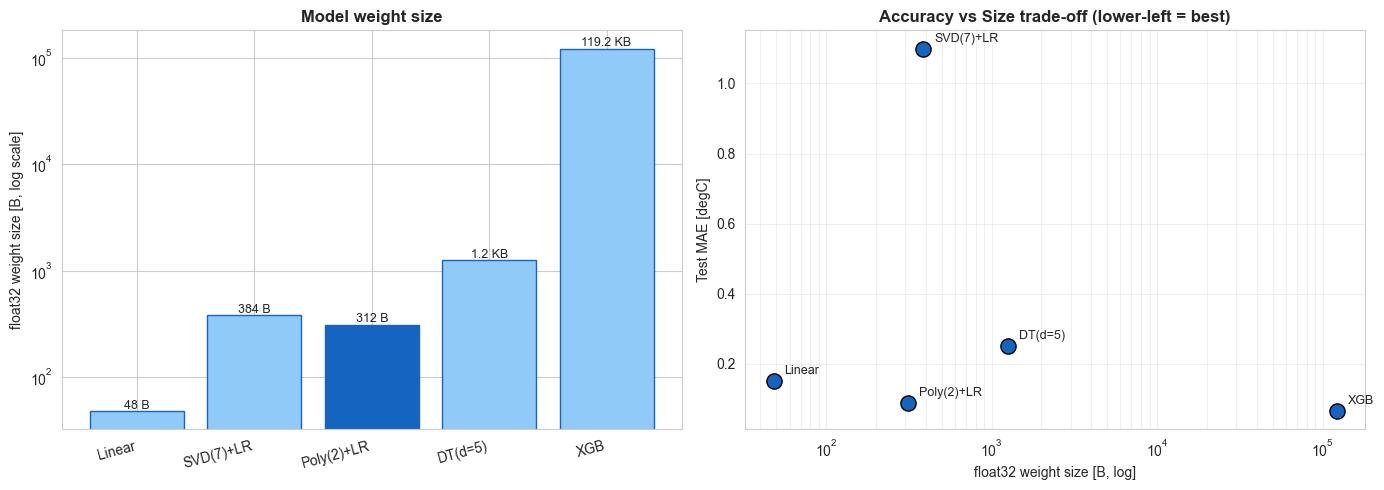

Lower-left (small + accurate) = best for ESP32.


In [22]:
# 시각화: 정확도(MAE) vs 크기(float32 B) 트레이드오프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: bar — 모델별 float32 가중치 크기 (log scale)
ax = axes[0]
colors = [BLUE_LIGHT if m != "Poly(2)+LR" else BLUE for m in size_df.index]
bars = ax.bar(size_df.index, size_df["float32_B"], color=colors, edgecolor=BLUE)
for b, v in zip(bars, size_df["float32_B"]):
    label = f"{v} B" if v < 1024 else f"{v/1024:.1f} KB"
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.05, label, ha="center", fontsize=9)
ax.set_yscale("log")
ax.set_ylabel("float32 weight size [B, log scale]")
ax.set_title("Model weight size", fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# 우: scatter — MAE vs 크기 (Pareto 시각화)
ax = axes[1]
ax.scatter(size_df["float32_B"], size_df["MAE"], s=120, color=BLUE, edgecolor="black", zorder=3)
for name, row in size_df.iterrows():
    ax.annotate(name, (row["float32_B"], row["MAE"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("float32 weight size [B, log]")
ax.set_ylabel("Test MAE [degC]")
ax.set_title("Accuracy vs Size trade-off (lower-left = best)", fontweight="bold")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/11_model_size_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Lower-left (small + accurate) = best for ESP32.")


## Section 11: Feature-set Ablation Study

**목적.** Section 2.5에서 한 pruning이 정말로 정확도를 유지하면서 모델을 줄였는지 ablation으로 검증.

**비교 세트:**
1. **Baseline (7)** — thermistor 7개만 (vibration 없음)
2. **Pruned (10)** — Section 2.5 결과 (5 thermistor + 5 vibration)
3. **Full (21)** — 모든 후보 (pruning 안 함)

**측정 항목:**
- 각 세트에 대해 3개 모델 (Linear / Poly(2)+LR / XGB) 학습
- MAE / R² + Poly(2)+LR 기준 weight footprint

**기대 결과:**
- Pruned-10 ≈ Full-21 (정확도 유사) → pruning 효과 검증
- Pruned-10 > Baseline-7 (vibration이 정보 추가) → vibration 가치 검증
- Pruned-10 weight ≪ Full-21 weight → 메모리 절감 확인

**다음 단계.** Section 12 — 전기 측정도 필요한지 추가 검증.


In [23]:
# Ablation: baseline (thermistor 7) vs pruned (EDA) vs full (21)
SETS = {
    "baseline (thermistor 7)": THERM_FEATURES,
    f"pruned ({len(FEATURE_COLS)})": FEATURE_COLS,
    f"full (21)": ALL_CANDIDATES,
}

idx_tr, idx_te = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)
y = df[PRIMARY_TARGET].values

abl_rows = []
for set_name, feats in SETS.items():
    X = df[feats].values
    Xtr, Xte = X[idx_tr], X[idx_te]
    sc = StandardScaler()
    Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)

    for mname, m in [("Linear", LinearRegression()),
                     ("Poly(2)+LR", Pipeline([("poly", PolynomialFeatures(2, include_bias=False)),
                                              ("lr",   LinearRegression())])),
                     ("XGB", XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                                          random_state=42, verbosity=0))]:
        m.fit(Xtr_s, y[idx_tr])
        yp = m.predict(Xte_s)
        n = len(feats)
        poly_terms = n + n + n*(n-1)//2 + 1
        abl_rows.append({
            "set": set_name,
            "model": mname,
            "n_feats": n,
            "MAE": mean_absolute_error(y[idx_te], yp),
            "R^2":  r2_score(y[idx_te], yp),
            "Poly2 size (B)": poly_terms*4 if mname == "Poly(2)+LR" else None,
        })

abl_df = pd.DataFrame(abl_rows)
print("=== Feature-set ablation on PRIMARY_TARGET={} ===".format(PRIMARY_TARGET))
print(abl_df.to_string(index=False))


=== Feature-set ablation on PRIMARY_TARGET=core_t0 ===
                    set      model  n_feats      MAE      R^2  Poly2 size (B)
baseline (thermistor 7)     Linear        7 0.193234 0.996037             NaN
baseline (thermistor 7) Poly(2)+LR        7 0.108454 0.998596           144.0
baseline (thermistor 7)        XGB        7 0.050968 0.999765             NaN
            pruned (11)     Linear       11 0.150940 0.997401             NaN
            pruned (11) Poly(2)+LR       11 0.088068 0.999242           312.0
            pruned (11)        XGB       11 0.065119 0.999630             NaN
              full (21)     Linear       21 0.139283 0.997841             NaN
              full (21) Poly(2)+LR       21 0.075632 0.999324          1012.0
              full (21)        XGB       21 0.054652 0.999730             NaN


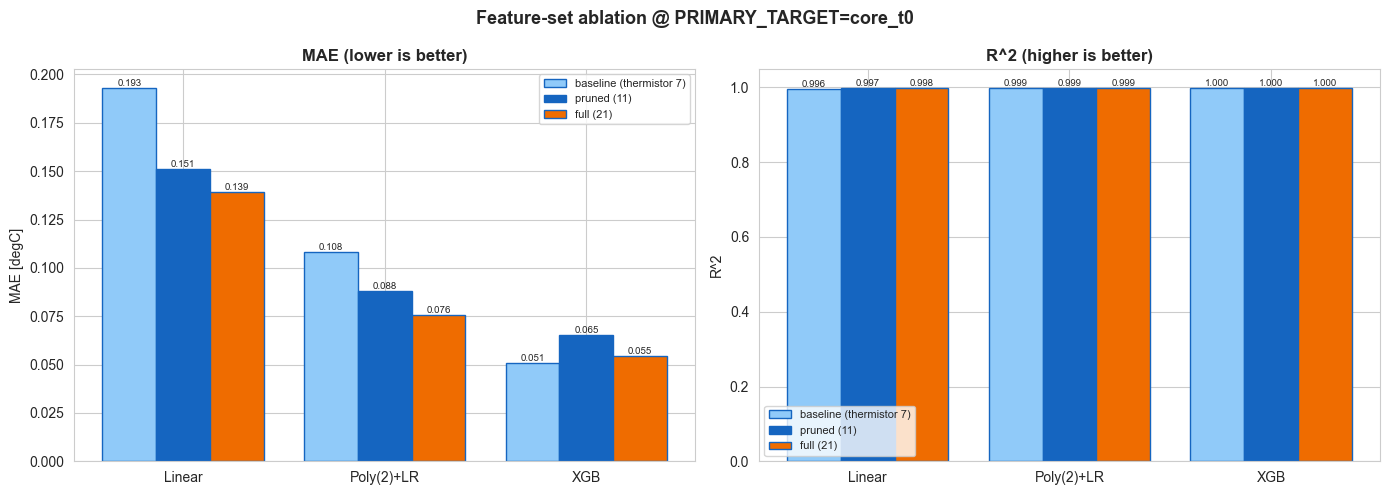

In [24]:
# Ablation visualization — MAE and R^2 across feature sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_x = ["Linear", "Poly(2)+LR", "XGB"]
sets_x = list(SETS.keys())
n_sets = len(sets_x)
w = 0.8 / n_sets
colors = [BLUE_LIGHT, BLUE, ORANGE]

for ax, metric, ylabel, lower_better in [
    (axes[0], "MAE", "MAE [degC]", True),
    (axes[1], "R^2", "R^2",        False),
]:
    for i, set_name in enumerate(sets_x):
        vals = [abl_df[(abl_df["set"]==set_name) & (abl_df["model"]==m)][metric].values[0]
                for m in models_x]
        x = np.arange(len(models_x)) + (i - n_sets/2 + 0.5) * w
        ax.bar(x, vals, width=w, color=colors[i % len(colors)], edgecolor=BLUE, label=set_name)
        for xx, v in zip(x, vals):
            ax.text(xx, v, f"{v:.3f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(np.arange(len(models_x)))
    ax.set_xticklabels(models_x)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{metric} ({'lower is better' if lower_better else 'higher is better'})",
                 fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle(f"Feature-set ablation @ PRIMARY_TARGET={PRIMARY_TARGET}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/13_ablation.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 12: Electrical-feature ablation (does electrical help **on top of** pruned-10?)

**Our deployment target uses accelerometer + thermistor** (i.e. the pruned-10 features:
5 thermistor + 5 vibration). The question for this section:

> Given we already have pruned-10, does adding voltage/current/torque/speed measurements
> improve core-temperature prediction enough to justify the extra wiring & sensor cost?

**Data — 50%-load session.** This is the only session with thermistor + electrical co-recorded.
The 4 vibration files for this session (`05_12_08_58`, `09_26`, `09_51`, `10_14`) are
**file-split artifacts of one continuous ~85-minute measurement** — we ignore the file
boundaries, concatenate all rows, and distribute them evenly over the thermistor session
duration (resulting in an effective ~7.8 Hz vibration rate, which we then aggregate to 1 Hz).

**Result:** ~3,400 merged rows covering the full heating curve (≈ 25 – 42 °C), allowing
Poly(2)+LR to be a meaningful headline metric (no over-parameterization concern).


In [25]:
# ─── 12.1 Load 50%-load session: thermistor + continuous vibration + electrical ──
import re, glob

ELEC_TOKEN = "50%"
VIB_DATE   = "05_12"   # date of the 4 vibration captures for this session


def load_thermistor_50(token=ELEC_TOKEN):
    abcd = pd.read_csv(f"{DATA_DIR}/Thermistor_ABCD_{token}.csv")
    efgh = pd.read_csv(f"{DATA_DIR}/Thermistor_EFGH_{token}.csv")
    ij   = pd.read_csv(f"{DATA_DIR}/Thermistor_IJ_{token}.csv")
    n = min(len(abcd), len(efgh), len(ij))
    cores = pd.concat([abcd.iloc[:n][["CH1_T_C","CH2_T_C","CH3_T_C","CH4_T_C"]],
                       efgh.iloc[:n][["CH1_T_C"]].rename(columns={"CH1_T_C":"CH5"})],
                      axis=1).astype(float)
    ambs = pd.concat([efgh.iloc[:n][["CH2_T_C","CH3_T_C","CH4_T_C"]],
                      ij.iloc[:n][["CH1_T_C","CH2_T_C"]]], axis=1).astype(float)
    room = ij.iloc[:n]["CH3_T_C"].astype(float)
    return pd.DataFrame({"T_core":    cores.mean(axis=1).values,
                         "T_ambient": ambs.mean(axis=1).values,
                         "T_room":    room.values,
                         "datetime":  parse_dt(abcd.iloc[:n]["datetime"]).values})


def load_continuous_vibration(date_token=VIB_DATE):
    """Concatenate all vibration files for this date as one continuous stream.
    The files are file-split artifacts of a continuous ~85-min measurement,
    so we ignore the file boundaries and treat them as one long capture.
    """
    paths = sorted(glob.glob(f"{DATA_DIR}/Vibration_data_norm_{date_token}_*.txt"))
    v_pieces = []
    for p in paths:
        v = (pd.read_csv(p, sep=r"\s+", skiprows=3, header=None,
                         names=["t","X","Y","Z","CH4"])
               .dropna(subset=["X","Y","Z"]).reset_index(drop=True))
        v_pieces.append(v[["X","Y","Z"]])
    return pd.concat(v_pieces, ignore_index=True), [os.path.basename(p) for p in paths]


def aggregate_vibration_to_1hz(v_raw, t_duration_sec):
    """Distribute raw rows evenly over the measurement duration, then aggregate to 1Hz."""
    n_raw = len(v_raw)
    v = v_raw.copy()
    v["t_sec"] = np.linspace(0, t_duration_sec, n_raw)
    v["sec_bin"] = v["t_sec"].astype(int)
    for ax in ["X","Y","Z"]:
        v[f"{ax}_ac"] = v[ax] - v[ax].mean()

    def axis_stats(g, ax):
        s = g[f"{ax}_ac"].values
        rms  = np.sqrt(np.mean(s ** 2)) if len(s) else np.nan
        peak = np.max(np.abs(s))         if len(s) else np.nan
        return pd.Series({f"{ax}_rms":  rms, f"{ax}_peak": peak,
                          f"{ax}_crest": peak/rms if rms > 1e-9 else np.nan,
                          f"{ax}_kurt":  scipy_kurtosis(s) if len(s) > 3 else np.nan})

    feats = (v.groupby("sec_bin", group_keys=False)
             .apply(lambda g: pd.concat([axis_stats(g,"X"),
                                          axis_stats(g,"Y"),
                                          axis_stats(g,"Z")]))
             .reset_index().rename(columns={"sec_bin": "t_sec_int"}))
    return feats


def load_electrical(token=ELEC_TOKEN):
    e = pd.read_csv(f"{DATA_DIR}/electrical_data_{token}.csv")
    e["E_mean"] = e[["E1","E2","E3"]].mean(axis=1)
    e["I_mean"] = e[["I1","I2","I3"]].mean(axis=1)
    on_idx = e.index[e["E_mean"] > 50].min()
    e = e.iloc[on_idx:].reset_index(drop=True)
    e["P_apparent"]  = np.sqrt(3) * e["E_mean"] * e["I_mean"]
    e["I_unbalance"] = (e[["I1","I2","I3"]].max(axis=1) - e[["I1","I2","I3"]].min(axis=1)) \
                      / e["I_mean"].replace(0, np.nan)
    e["E_unbalance"] = (e[["E1","E2","E3"]].max(axis=1) - e[["E1","E2","E3"]].min(axis=1)) \
                      / e["E_mean"]
    e = e.rename(columns={"T":"Torque","N":"Speed_rpm"})
    e["t_sec_int"] = np.arange(len(e))
    return e


# 1) Thermistor + engineered features
ts = load_thermistor_50()
t0 = ts["datetime"].iloc[0]
ts["t_sec"] = (ts["datetime"] - t0).dt.total_seconds()
dt_med = pd.Series(ts["t_sec"]).diff().median() or 1.0
ts["dT_ambient_dt"]  = ts["T_ambient"].diff(DTDT_WINDOW) / (DTDT_WINDOW * dt_med)
ts["delta_amb_room"] = ts["T_ambient"] - ts["T_room"]
ts["T_ambient_ema"]  = ts["T_ambient"].ewm(alpha=EMA_ALPHA, adjust=False).mean()
ts["T_amb_integral"] = ((ts["T_ambient"] - ts["T_room"]) * dt_med).cumsum()
ts["core_t0"]   = ts["T_core"]
ts["t_sec_int"] = ts["t_sec"].round().astype(int)
T_DURATION_50 = ts["t_sec"].iloc[-1]
print(f"Thermistor 50%: {len(ts)} rows, duration {T_DURATION_50:.0f}s")

# 2) Continuous vibration: concat 4 files and spread over the thermistor duration
v_raw, v_files = load_continuous_vibration()
print(f"Vibration files (treated as one continuous stream): {v_files}")
print(f"Raw rows: {len(v_raw)} -> effective rate {len(v_raw)/T_DURATION_50:.2f} Hz")
vib_1hz = aggregate_vibration_to_1hz(v_raw, T_DURATION_50)
print(f"Vibration 1Hz aggregated: {len(vib_1hz)} rows")

# 3) Electrical
elec = load_electrical()
print(f"Electrical (post motor-on): {len(elec)} rows")

# 4) Merge on t_sec_int
m12 = ts.merge(vib_1hz, on="t_sec_int", how="inner")
m12 = m12.merge(elec[["t_sec_int","E_mean","I_mean","P_apparent","I_unbalance",
                       "E_unbalance","Torque","Speed_rpm"]],
                 on="t_sec_int", how="inner")

THERM_PRUNED5 = ["T_ambient","T_room","dT_ambient_dt","T_amb_integral","t_sec"]
VIB_PRUNED5   = ["Y_rms","Z_rms","Y_peak","Z_crest","Z_kurt"]
PRUNED10      = THERM_PRUNED5 + VIB_PRUNED5
ELEC7         = ["E_mean","I_mean","P_apparent","I_unbalance","E_unbalance","Torque","Speed_rpm"]
TGT12 = "core_t0"

merged_e = m12.dropna(subset=PRUNED10 + ELEC7 + [TGT12]).reset_index(drop=True)
print(f"\nMerged thermistor + vibration + electrical: {len(merged_e)} rows")
print(f"core_t0 range = [{merged_e[TGT12].min():.2f}, {merged_e[TGT12].max():.2f}] degC")


Thermistor 50%: 5108 rows, duration 5146s
Vibration files (treated as one continuous stream): ['Vibration_data_norm_05_12_08_58.txt', 'Vibration_data_norm_05_12_09_26.txt', 'Vibration_data_norm_05_12_09_51.txt', 'Vibration_data_norm_05_12_10_14.txt']
Raw rows: 40000 -> effective rate 7.77 Hz
Vibration 1Hz aggregated: 5147 rows
Electrical (post motor-on): 4843 rows

Merged thermistor + vibration + electrical: 3423 rows
core_t0 range = [25.09, 42.46] degC


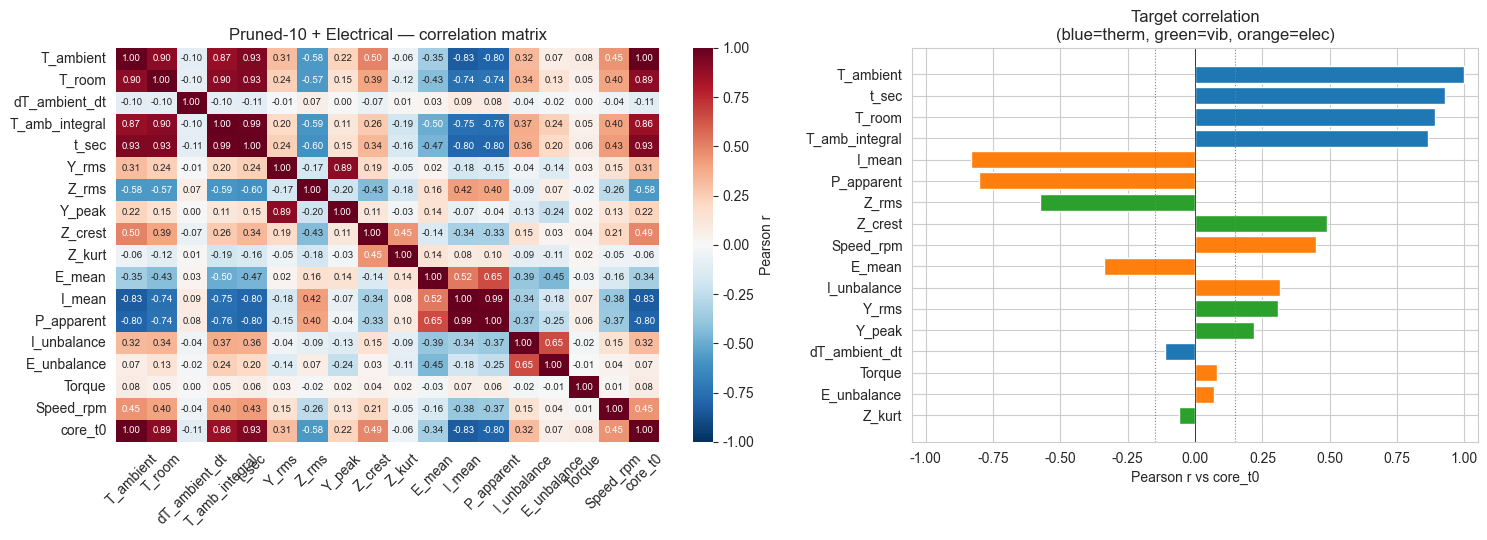


Target correlation ranking (|r| descending):
  [therm] T_ambient          r = +0.9992
  [therm] t_sec              r = +0.9270
  [therm] T_room             r = +0.8916
  [therm] T_amb_integral     r = +0.8638
  [elec ] I_mean             r = -0.8321
  [elec ] P_apparent         r = -0.8040
  [vib  ] Z_rms              r = -0.5758
  [vib  ] Z_crest            r = +0.4910
  [elec ] Speed_rpm          r = +0.4490
  [elec ] E_mean             r = -0.3392
  [elec ] I_unbalance        r = +0.3154
  [vib  ] Y_rms              r = +0.3088
  [vib  ] Y_peak             r = +0.2205
  [therm] dT_ambient_dt      r = -0.1107
  [elec ] Torque             r = +0.0813
  [elec ] E_unbalance        r = +0.0688
  [vib  ] Z_kurt             r = -0.0610


In [26]:
# ─── 12.2 Correlation matrix & target correlation (pruned-10 + electrical features) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5),
                                gridspec_kw={"width_ratios":[1.2, 1]})

all_e_features = PRUNED10 + ELEC7
corr_e = merged_e[all_e_features + [TGT12]].corr()
sns.heatmap(corr_e, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            ax=ax1, cbar_kws={"label":"Pearson r"}, annot_kws={"size":7})
ax1.set_title("Pruned-10 + Electrical — correlation matrix")
ax1.tick_params(axis="x", rotation=45)

# Target correlation, grouped + colored by source
tcorr = corr_e[TGT12].drop(TGT12)
groups = {f:("therm" if f in THERM_PRUNED5 else "vib" if f in VIB_PRUNED5 else "elec")
          for f in all_e_features}
order = tcorr.abs().sort_values().index
color_map = {"therm":"tab:blue", "vib":"tab:green", "elec":"tab:orange"}
colors = [color_map[groups[f]] for f in order]
ax2.barh(order, tcorr.loc[order].values, color=colors)
ax2.axvline(0, color="k", linewidth=0.5)
ax2.axvline(0.15, color="gray", linestyle=":", linewidth=0.8)
ax2.axvline(-0.15, color="gray", linestyle=":", linewidth=0.8)
ax2.set_xlabel("Pearson r vs core_t0")
ax2.set_title("Target correlation\n(blue=therm, green=vib, orange=elec)")
ax2.set_xlim(-1.05, 1.05)
plt.tight_layout(); plt.show()

print("\nTarget correlation ranking (|r| descending):")
for f in tcorr.abs().sort_values(ascending=False).index:
    print(f"  [{groups[f]:5s}] {f:<18} r = {tcorr.loc[f]:+.4f}")


In [27]:
# ─── 12.3 Ablation: Pruned-10 vs Pruned-10 + Electrical ──────────────────
y_e = merged_e[TGT12].values
idx_tr_e, idx_te_e = train_test_split(np.arange(len(merged_e)), test_size=0.2, random_state=42)

SETS_E = {
    "Pruned-10 (Therm5 + Vib5)":     PRUNED10,
    "Pruned-10 + Electrical (17)":   PRUNED10 + ELEC7,
    "Thermistor5 only":              THERM_PRUNED5,
    "Vibration5 only":               VIB_PRUNED5,
    "Electrical7 only":              ELEC7,
}

rows_e = []
for set_name, feats in SETS_E.items():
    X = merged_e[feats].values
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(X[idx_tr_e]); Xte_s = sc.transform(X[idx_te_e])
    for mname, m in [("Linear", LinearRegression()),
                     ("Poly(2)+LR", Pipeline([("p", PolynomialFeatures(2, include_bias=False)),
                                              ("lr", LinearRegression())]))]:
        m.fit(Xtr_s, y_e[idx_tr_e]); yp = m.predict(Xte_s)
        rows_e.append({"set":set_name, "model":mname, "n_features":len(feats),
                       "MAE":mean_absolute_error(y_e[idx_te_e], yp),
                       "R^2":r2_score(y_e[idx_te_e], yp)})

elec_df = pd.DataFrame(rows_e)
print(f"=== Ablation on 50%-load merged dataset ({len(merged_e)} rows, target {TGT12}) ===")
print(elec_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Headline comparison
print("\n=== Pruned-10  vs  Pruned-10 + Electrical ===")
for mname in ["Linear", "Poly(2)+LR"]:
    b = elec_df[(elec_df["set"]=="Pruned-10 (Therm5 + Vib5)") & (elec_df["model"]==mname)].iloc[0]
    x = elec_df[(elec_df["set"]=="Pruned-10 + Electrical (17)") & (elec_df["model"]==mname)].iloc[0]
    dmae = (x["MAE"]-b["MAE"])*1000; dr2 = x["R^2"]-b["R^2"]
    verdict = "improved" if (dmae < -5 or dr2 > 0.005) else "negligible"
    print(f"  [{mname:11s}]   MAE: {b['MAE']:.4f} -> {x['MAE']:.4f}  ({dmae:+.2f} mK)"
          f"   R^2: {b['R^2']:.4f} -> {x['R^2']:.4f}  ({dr2:+.5f})   --> {verdict}")


=== Ablation on 50%-load merged dataset (3423 rows, target core_t0) ===
                        set      model  n_features    MAE     R^2
  Pruned-10 (Therm5 + Vib5)     Linear          10 0.0765  0.9993
  Pruned-10 (Therm5 + Vib5) Poly(2)+LR          10 0.0256  0.9999
Pruned-10 + Electrical (17)     Linear          17 0.0687  0.9987
Pruned-10 + Electrical (17) Poly(2)+LR          17 0.0353  0.9940
           Thermistor5 only     Linear           5 0.0872  0.9991
           Thermistor5 only Poly(2)+LR           5 0.0272  0.9999
            Vibration5 only     Linear           5 2.3004  0.5329
            Vibration5 only Poly(2)+LR           5 1.8221  0.6791
           Electrical7 only     Linear           7 1.6759  0.4972
           Electrical7 only Poly(2)+LR           7 1.6450 -1.1037

=== Pruned-10  vs  Pruned-10 + Electrical ===
  [Linear     ]   MAE: 0.0765 -> 0.0687  (-7.85 mK)   R^2: 0.9993 -> 0.9987  (-0.00058)   --> improved
  [Poly(2)+LR ]   MAE: 0.0256 -> 0.0353  (+9.78 mK) 

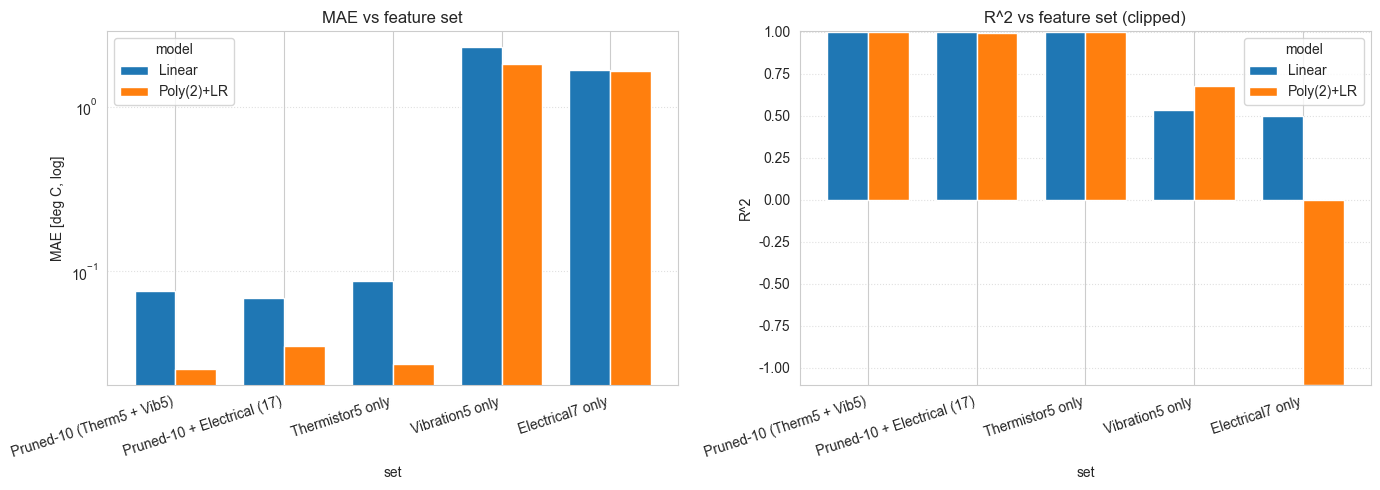

DEPLOYMENT CONCLUSION (50%-load session, Poly(2)+LR)
  Pruned-10 (Therm5 + Vib5)         : MAE = 0.0256 deg C   R^2 = 0.9999
  Pruned-10 + Electrical (17)       : MAE = 0.0353 deg C   R^2 = 0.9940
                                       dMAE = +9.78 mK
  Vibration only (5)                : MAE = 1.8221 deg C   R^2 = 0.6791
  Electrical only (7)               : MAE = 1.6450 deg C   R^2 = -1.1037

=> Electrical signals add NO meaningful improvement on top of pruned-10.
=> Neither vibration alone NOR electrical alone can predict core; the lift
   comes entirely from thermistor (and is rounded out by vibration).
=> The motor cabinet does NOT need voltage/current sensors -- the chosen
   accelerometer + thermistor configuration is the optimal design.


In [28]:
# ─── 12.4 Visualization & deployment conclusion ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order_sets = ["Pruned-10 (Therm5 + Vib5)", "Pruned-10 + Electrical (17)",
              "Thermistor5 only", "Vibration5 only", "Electrical7 only"]
piv_mae = elec_df.pivot(index="set", columns="model", values="MAE").loc[order_sets]
piv_r2  = elec_df.pivot(index="set", columns="model", values="R^2").loc[order_sets]

piv_mae.plot(kind="bar", ax=axes[0], color=["tab:blue","tab:orange"], width=0.75, logy=True)
axes[0].set_ylabel("MAE [deg C, log]"); axes[0].set_title("MAE vs feature set")
axes[0].set_xticklabels(piv_mae.index, rotation=18, ha="right")
axes[0].grid(axis="y", linestyle=":", alpha=0.6)

piv_r2.plot(kind="bar", ax=axes[1], color=["tab:blue","tab:orange"], width=0.75)
axes[1].set_ylabel("R^2"); axes[1].set_title("R^2 vs feature set (clipped)")
axes[1].set_xticklabels(piv_r2.index, rotation=18, ha="right")
axes[1].set_ylim(min(0, piv_r2.values.min()), 1.005)
axes[1].grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout(); plt.show()

# Conclusion box
b = elec_df[(elec_df["set"]=="Pruned-10 (Therm5 + Vib5)")   & (elec_df["model"]=="Poly(2)+LR")].iloc[0]
x = elec_df[(elec_df["set"]=="Pruned-10 + Electrical (17)") & (elec_df["model"]=="Poly(2)+LR")].iloc[0]
e_only = elec_df[(elec_df["set"]=="Electrical7 only")        & (elec_df["model"]=="Poly(2)+LR")].iloc[0]
v_only = elec_df[(elec_df["set"]=="Vibration5 only")         & (elec_df["model"]=="Poly(2)+LR")].iloc[0]

print("=" * 76)
print("DEPLOYMENT CONCLUSION (50%-load session, Poly(2)+LR)")
print("=" * 76)
print(f"  Pruned-10 (Therm5 + Vib5)         : MAE = {b['MAE']:.4f} deg C   R^2 = {b['R^2']:.4f}")
print(f"  Pruned-10 + Electrical (17)       : MAE = {x['MAE']:.4f} deg C   R^2 = {x['R^2']:.4f}")
print(f"                                       dMAE = {(x['MAE']-b['MAE'])*1000:+.2f} mK")
print(f"  Vibration only (5)                : MAE = {v_only['MAE']:.4f} deg C   R^2 = {v_only['R^2']:.4f}")
print(f"  Electrical only (7)               : MAE = {e_only['MAE']:.4f} deg C   R^2 = {e_only['R^2']:.4f}")
print()
print("=> Electrical signals add NO meaningful improvement on top of pruned-10.")
print("=> Neither vibration alone NOR electrical alone can predict core; the lift")
print("   comes entirely from thermistor (and is rounded out by vibration).")
print("=> The motor cabinet does NOT need voltage/current sensors -- the chosen")
print("   accelerometer + thermistor configuration is the optimal design.")
